<a href="https://colab.research.google.com/github/cesarrossi245-ux/eda-personas-desaparecidas/blob/main/3EDA_Personas_Desaparecidas_Peru2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis Exploratorio de Datos y Preprocesamiento: Personas desaparecidas en el Perú (2019–2025)**

> *Exploración, limpieza y preparación de datos para aprendizaje automático con el conjunto de datos abiertos
> «Personas desaparecidas» del Ministerio del Interior.*

**Profesora:** Dra. Nancy Baygorrea  **Curso:** MCD-104 Fundamentos de Ciencia de Datos e Inteligencia Artificial (2026-II)
**Autor:** Cesar Rossi Ypanaque — Escuela de Posgrado, Universidad Nacional de Juliaca

**Conjunto de datos:** *DataSet Personas desaparecidas – Enero 2019 a Diciembre 2025* (MININTER, Plataforma Nacional de Datos
Abiertos, licencia ODC-By), con su diccionario de datos oficial. Cada fila es un **conteo agregado** (`CANTIDAD`) de personas que
comparten año, mes, distrito (UBIGEO), sexo, rango de edad y nacionalidad.

**Problema (Actividad 1):** clasificar el **nivel de riesgo** $Y \in \{\text{Bajo}, \text{Medio}, \text{Alto}\}$ de cada
**departamento-mes**, definido por terciles del número de personas reportadas (umbrales calculados solo con 2019–2023).

Este cuaderno sigue los **11 pasos del cuaderno de clase** `adult_census_data_EDA.ipynb` (carga → faltantes → numéricos →
categóricos → tablas cruzadas → segmentos → comparación de clases → One-Hot → correlación → discretización → escalamiento) y los
complementa con el protocolo de las diapositivas *Análisis Exploratorio de Datos* y del cuaderno `adult_sesion1_fundamentos.ipynb`
(procedencia, diccionario analítico, mecanismo de ausencia, regla de Tukey, ECDF, fuga de información y bitácora de decisiones).

> **Principio:** *No se debe modelar lo que todavía no se ha comprendido.* El EDA permite describir, detectar y formular
> hipótesis; no prueba causalidad ni garantiza generalización.

## Paso 0: Entorno computacional y reproducibilidad
Registramos versiones de Python y bibliotecas y fijamos una semilla. La semilla no elimina el carácter aleatorio de un
procedimiento: permite repetir la misma ejecución bajo el mismo entorno, datos y parámetros.

In [2]:
import sys, platform, hashlib, re, unicodedata, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler,
                                   RobustScaler, FunctionTransformer)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

display(pd.Series({
    "python": sys.version.split()[0], "plataforma": platform.platform(), "numpy": np.__version__,
    "pandas": pd.__version__, "scipy": scipy.__version__, "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__, "scikit-learn": sklearn.__version__, "semilla": RANDOM_STATE,
}, name="versión").to_frame())

# Estilo gráfico común: marcas finas, rejilla recesiva y paleta categórica fija
AZUL, NARANJA, VERDEAGUA, GRIS = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.edgecolor": "#52514e",
    "axes.labelcolor": "#0b0b0b", "xtick.color": "#52514e", "ytick.color": "#52514e",
})
def nombre_bonito(d):
    return " ".join(w.capitalize() if w not in {"DE", "LA"} or i == 0 else w.lower() for i, w in enumerate(d.split()))

def cramers_v(tabla):
    chi2, p, dof, _ = stats.chi2_contingency(tabla, correction=False)
    n = np.asarray(tabla).sum(); r, k = np.asarray(tabla).shape
    return chi2, dof, p, np.sqrt(chi2 / (n * (min(r, k) - 1)))

FIG_DIR = Path("figuras"); FIG_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("salidas_eda"); OUT_DIR.mkdir(exist_ok=True)

,versión
python,3.13.16
plataforma,Linux-6.6.122+-x86_64-with-glibc2.39
numpy,2.1.3
pandas,2.2.3
scipy,1.16.3
matplotlib,3.10.0
seaborn,0.13.2
scikit-learn,1.6.1
semilla,42


### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Con qué herramientas trabajamos y cómo garantizamos que otra persona obtenga los mismos resultados?

**🛠️ ¿Cómo lo hicimos?**  
Anotamos la versión de Python y de cada librería, y fijamos una «semilla». La semilla es como decirle a la computadora: «cada vez que tengas que elegir algo al azar, hazlo siempre de la misma manera».

**📊 ¿Qué encontramos?**

- El análisis se hizo en Python con pandas (tablas), matplotlib y seaborn (gráficos) y scikit-learn (preparación para modelos).
- Si alguien vuelve a correr este cuaderno con los mismos archivos, obtendrá exactamente los mismos números y gráficos.

**💡 ¿Qué significa?**  
El trabajo se puede repetir y revisar. Eso es lo que la ciencia de datos llama reproducibilidad.

## Paso 1: Carga y exploración inicial de los datos
Cargamos el conjunto de datos y su diccionario oficial, verificamos la integridad del archivo (SHA-256) y exploramos sus
características generales: primeras filas, tipos, valores no nulos y estadísticos de todos los atributos.

**Archivos que se deben subir a la carpeta de trabajo** (en Google Colab: panel *Archivos* → *Subir*):

| Archivo | Fuente oficial |
|---|---|
| CSV de personas desaparecidas (cualquier nombre que contenga «desaparecidas») | MININTER, Plataforma Nacional de Datos Abiertos: https://www.datosabiertos.gob.pe/dataset/personas-desaparecidas |
| Diccionario de datos (Excel cuyo nombre contenga «diccionario») | MININTER, mismo conjunto de datos |
| Población proyectada del INEI (Excel cuyo nombre contenga «INEI» o «población») | INEI, *Perú: Población total proyectada al 30 de junio de cada año, según departamento, provincia y distrito, 2018–2026* (Cuadro N.° 01): https://www.gob.pe/institucion/inei/informes-publicaciones/6894980-peru-poblacion-total-proyectada-al-30-de-junio-de-cada-ano-segun-departamento-provincia-y-distrito-2018-2026 |

Si falta un archivo y el cuaderno se ejecuta en Colab, se abre un botón para subirlo.

In [5]:
def buscar_archivo(palabras, extension, descripcion):
    # Busca en la carpeta de trabajo un archivo cuyo nombre contenga alguna de las palabras (sin importar
    # mayúsculas, espacios o guiones bajos); en Colab, si no está, pide subirlo.
    def buscar():
        norm = lambda t: re.sub(r"[^a-z0-9]", "", t.lower())
        return sorted(p for p in Path(".").glob("*" + extension) if any(norm(w) in norm(p.name) for w in palabras))
    encontrados = buscar()
    if not encontrados:
        try:
            from google.colab import files
            print(f"Suba el archivo: {descripcion}")
            files.upload()
            encontrados = buscar()
        except ImportError:
            pass
    if not encontrados:
        raise FileNotFoundError(f"No se encontró {descripcion} en la carpeta de trabajo.")
    return encontrados[0]

DATA_FILE = buscar_archivo(["desaparecid"], ".csv", "el CSV de personas desaparecidas del MININTER")
POP_FILE = buscar_archivo(["inei", "poblacion"], ".xlsx", "la población proyectada del INEI 2018–2026")
DICT_CANDIDATOS = [p for p in Path(".").glob("*.xlsx") if "diccionario" in p.name.lower()]
DICT_FILE = DICT_CANDIDATOS[0] if DICT_CANDIDATOS else None
SHA_ESPERADO = "c41ebcced14fdf86bbf17db9f54bb381d73c0464a402f22ac5548a7899ef0e32"   # versión descargada para este estudio

sha256 = hashlib.sha256(DATA_FILE.read_bytes()).hexdigest()
print("Archivo:", DATA_FILE.name, "| bytes:", f"{DATA_FILE.stat().st_size:,}")
print("SHA-256:", sha256, "| coincide con la versión analizada en el manuscrito:", sha256 == SHA_ESPERADO)
print("Diccionario:", DICT_FILE.name if DICT_FILE else "no se subió; se usa la transcripción incluida abajo")
print("Población INEI:", POP_FILE.name)

# Lectura 1: tipos inferidos (como haría un usuario sin experiencia). Lectura 2: todo como texto.
raw_inferido = pd.read_csv(DATA_FILE, encoding="latin-1")
raw = pd.read_csv(DATA_FILE, encoding="latin-1", dtype=str, keep_default_na=False)
print("Dimensión (N × d):", raw.shape)
raw_inferido.head(10)

Suba el archivo: la población proyectada del INEI 2018–2026


Saving INEI_Poblacion_proyectada_2018-2026.xlsx to INEI_Poblacion_proyectada_2018-2026.xlsx
Archivo: DATASET_Personas Desaparecidas - Enero 2019 a Diciembre 2025 (1).csv | bytes: 5,068,176
SHA-256: c41ebcced14fdf86bbf17db9f54bb381d73c0464a402f22ac5548a7899ef0e32 | coincide con la versión analizada en el manuscrito: True
Diccionario: no se subió; se usa la transcripción incluida abajo
Población INEI: INEI_Poblacion_proyectada_2018-2026.xlsx
Dimensión (N × d): (77331, 10)


,AÑO,MES,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,SEXO,RANGO_EDAD,NACIONALIDAD,CANTIDAD
0,2019,5,150120,LIMA METROPOLITANA,LIMA,MAGDALENA DEL MAR,M,60 A MAS AÑOS,PERÚ,1
1,2025,3,200304,PIURA,HUANCABAMBA,HUARMACA,F,12-17 AÑOS,PERÚ,1
2,2020,11,120421,JUNÍN,JAUJA,MUQUIYAUYO,F,12-17 AÑOS,PERÚ,1
3,2024,2,200115,PIURA,PIURA,26 DE OCTUBRE,F,6-11 AÑOS,PERÚ,1
4,2024,7,150133,LIMA METROPOLITANA,LIMA,SAN JUAN DE MIRAFLORES,M,18-29 AÑOS,PERÚ,3
5,2020,4,21801,ÁNCASH,SANTA,CHIMBOTE,F,18-29 AÑOS,VENEZUELA,1
6,2019,9,20601,ÁNCASH,CARHUAZ,CARHUAZ,M,12-17 AÑOS,PERÚ,1
7,2021,8,20611,ÁNCASH,CARHUAZ,YUNGAR,M,60 A MAS AÑOS,PERÚ,1
8,2023,3,150605,REGIÓN LIMA,HUARAL,CHANCAY,M,6-11 AÑOS,PERÚ,1
9,2025,3,140301,LAMBAYEQUE,LAMBAYEQUE,LAMBAYEQUE,F,12-17 AÑOS,VENEZUELA,1


In [6]:
raw_inferido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77331 entries, 0 to 77330
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   AÑO           77331 non-null  int64 
 1   MES           77331 non-null  int64 
 2   UBIGEO_HECHO  77331 non-null  int64 
 3   DPTO_HECHO    77331 non-null  object
 4   PROV_HECHO    77331 non-null  object
 5   DIST_HECHO    77331 non-null  object
 6   SEXO          77248 non-null  object
 7   RANGO_EDAD    76134 non-null  object
 8   NACIONALIDAD  77331 non-null  object
 9   CANTIDAD      77331 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 5.9+ MB


In [7]:
raw_inferido.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AÑO,77331.0,NaN,NaN,NaN,2021.968538,2.035913,2019.0,2020.0,2022.0,2024.0,2025.0
MES,77331.0,NaN,NaN,NaN,6.552236,3.495573,1.0,3.0,7.0,10.0,12.0
UBIGEO_HECHO,77331.0,NaN,NaN,NaN,125257.730367,58817.360162,10101.0,80108.0,140105.0,150142.0,250401.0
DPTO_HECHO,77331,26,LIMA METROPOLITANA,17829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PROV_HECHO,77331,195,LIMA,17829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DIST_HECHO,77331,1435,SAN JUAN DE LURIGANCHO,971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SEXO,77248,2,F,42010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RANGO_EDAD,76134,6,12-17 AÑOS,31926,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NACIONALIDAD,77331,60,PERÚ,74324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CANTIDAD,77331.0,NaN,NaN,NaN,1.841099,2.069369,1.0,1.0,1.0,2.0,53.0


In [8]:
# Integridad de tipos: el UBIGEO es un identificador de 6 dígitos, no un número
ubigeo_inferido = raw_inferido["UBIGEO_HECHO"].astype(str)
perdidos = int((ubigeo_inferido.str.len() == 5).sum())
print(f"Filas cuyo UBIGEO pierde el cero inicial con tipos inferidos: {perdidos:,} ({100 * perdidos / len(raw):.1f} % de las filas)")
codigos_perdidos = raw.loc[ubigeo_inferido.str.len() == 5, "UBIGEO_HECHO"].nunique()
print(f"Códigos UBIGEO distintos afectados: {codigos_perdidos:,} de {raw['UBIGEO_HECHO'].nunique():,} ({100 * codigos_perdidos / raw['UBIGEO_HECHO'].nunique():.1f} %)")
print("Ejemplo:", raw.loc[ubigeo_inferido.str.len() == 5, "UBIGEO_HECHO"].iloc[0], "→",
      ubigeo_inferido[ubigeo_inferido.str.len() == 5].iloc[0])

# Granularidad: ¿la combinación de atributos identifica cada fila?
clave = ["AÑO", "MES", "UBIGEO_HECHO", "SEXO", "RANGO_EDAD", "NACIONALIDAD"]
print("Duplicados exactos:", int(raw.duplicated().sum()), "| duplicados en la clave de agregación:", int(raw.duplicated(clave).sum()))
print("Personas reportadas (suma de CANTIDAD):", f"{raw['CANTIDAD'].astype(int).sum():,}")

Filas cuyo UBIGEO pierde el cero inicial con tipos inferidos: 23,735 (30.7 % de las filas)
Códigos UBIGEO distintos afectados: 724 de 1,549 (46.7 %)
Ejemplo: 021801 → 21801
Duplicados exactos: 0 | duplicados en la clave de agregación: 0
Personas reportadas (suma de CANTIDAD): 142,374


### 1.1 Contraste con el diccionario oficial
Leemos el diccionario publicado por el MININTER y lo comparamos, variable por variable, con lo que realmente contiene el archivo.

In [9]:
if DICT_FILE is not None:
    dic = pd.read_excel(DICT_FILE, header=3).dropna(how="all").dropna(axis=1, how="all")
    dic.columns = [str(c).strip() for c in dic.columns]
else:   # respaldo: transcripción del diccionario oficial del MININTER
    dic = pd.DataFrame({
        "Variable": ["AÑO", "MES", "UBIGEO", "DPTO_HECHO", "PROV_HECHO", "DIST_HECHO", "SEXO", "RANGO_EDAD", "NACIONALIDAD", "CANTIDAD"],
        "Tipo de dato": ["Cadena"] * 9 + ["Numérico"], "Tamaño": [4, 2, 6, 30, 30, 30, 1, 13, 14, 2],
        "Información Adicional": ["Formato: aaaammdd", None, None, None, None, None, "F:Femenino, M:Masculino", "Contiene valos vacios", None, None]})
dic = dic[["Variable", "Tipo de dato", "Tamaño", "Información Adicional"]]

columna_archivo = {v: ("UBIGEO_HECHO" if v == "UBIGEO" else v) for v in dic["Variable"]}
contraste = dic.copy()
contraste["columna_en_archivo"] = contraste["Variable"].map(columna_archivo)
contraste["existe_con_ese_nombre"] = contraste["Variable"].isin(raw.columns)
contraste["dtype_inferido"] = contraste["columna_en_archivo"].map(raw_inferido.dtypes.astype(str))
contraste["long_max_observada"] = contraste["columna_en_archivo"].map(raw.apply(lambda s: s.str.len().max()))
contraste["excede_tamano"] = contraste["long_max_observada"] > contraste["Tamaño"].astype(int)
contraste["vacios_observados"] = contraste["columna_en_archivo"].map((raw == "").sum())
contraste

,Variable,Tipo de dato,Tamaño,Información Adicional,columna_en_archivo,existe_con_ese_nombre,dtype_inferido,long_max_observada,excede_tamano,vacios_observados
0,AÑO,Cadena,4,Formato: aaaammdd,AÑO,True,int64,4,False,0
1,MES,Cadena,2,None,MES,True,int64,2,False,0
2,UBIGEO,Cadena,6,None,UBIGEO_HECHO,False,int64,6,False,0
3,DPTO_HECHO,Cadena,30,None,DPTO_HECHO,True,object,18,False,0
4,PROV_HECHO,Cadena,30,None,PROV_HECHO,True,object,25,False,0
5,DIST_HECHO,Cadena,30,None,DIST_HECHO,True,object,36,True,0
6,SEXO,Cadena,1,"F:Femenino, M:Masculino",SEXO,True,object,1,False,83
7,RANGO_EDAD,Cadena,13,Contiene valos vacios,RANGO_EDAD,True,object,13,False,1197
8,NACIONALIDAD,Cadena,14,None,NACIONALIDAD,True,object,25,True,0
9,CANTIDAD,Numérico,2,None,CANTIDAD,True,int64,2,False,0


### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Qué contiene el archivo, cuánta información hay y coincide con lo que dice el diccionario oficial?

**🛠️ ¿Cómo lo hicimos?**  
Abrimos el archivo, contamos filas y columnas, revisamos si había registros repetidos y comparamos cada columna con el diccionario de datos que publica el Ministerio del Interior.

**📊 ¿Qué encontramos?**

- El archivo tiene 77,331 filas y 10 columnas, y en total registra 142,374 personas desaparecidas entre 2019 y 2025.
- Cada fila no es una persona, sino un grupo: por ejemplo, «3 mujeres de 12 a 17 años, peruanas, desaparecidas en Ate en mayo de 2021». La columna CANTIDAD dice cuántas personas hay en ese grupo.
- No hay filas repetidas.
- Si dejamos que Python adivine el tipo de dato, el código de ubicación (UBIGEO) pierde el cero inicial (021801 se vuelve 21801) en casi un tercio de las filas. Por eso leímos todo como texto.
- Encontramos 6 diferencias con el diccionario oficial. Por ejemplo, una columna tiene otro nombre en el archivo, el año está descrito como una fecha completa y algunos textos son más largos de lo permitido.

**💡 ¿Qué significa?**  
Los datos están completos en volumen, pero la documentación oficial no describe bien el archivo. Esta es una primera señal sobre la calidad de los datos abiertos, que es justamente nuestro primer objetivo.

<details>
<summary><b>📐 Detalle técnico (cifras y pruebas estadísticas) — clic para ver</b></summary>

Leímos el archivo de dos formas. Con tipos inferidos, `pandas` convierte AÑO, MES, UBIGEO_HECHO y CANTIDAD en enteros y 23,735 filas (30.7 %) pierden el cero inicial de su UBIGEO (724 de los 1,549 códigos distintos) (por ejemplo, 021801 → 21801), lo que impide cruzarlos con el INEI; por eso todo se lee como texto. La tabla tiene 77,331 filas y 10 columnas (N ≫ d), sin duplicados exactos ni en la clave (año, mes, UBIGEO, sexo, rango de edad, nacionalidad): cada fila es una celda de conteo única y suma 142,374 personas. `info()` muestra que solo SEXO (77,248 no nulos) y RANGO_EDAD (76,134) tienen vacíos. `describe(include="all")` indica 26 departamentos, 195 provincias, 1,435 nombres de distrito, 60 nacionalidades y CANTIDAD entre 1 y 53 (media 1.84; mediana 1); la media de UBIGEO carece de sentido porque es un identificador, no una cantidad. El contraste con el diccionario oficial revela discrepancias: el nombre UBIGEO no existe en el archivo (se llama UBIGEO_HECHO); el formato de AÑO dice «aaaammdd», pero solo contiene el año; DIST_HECHO (36 caracteres) y NACIONALIDAD (25) superan los tamaños declarados (30 y 14); SEXO tiene 83 vacíos no documentados, y RANGO_EDAD advierte vacíos, pero no los cuantifica (1,197).

</details>

## Paso 2: Valores faltantes y limpieza de datos
Calculamos los faltantes de cada atributo. Como en el cuaderno de clase (donde `?` representaba la ausencia), primero revisamos los
valores únicos: aquí la ausencia aparece como **cadena vacía** y, de forma **encubierta**, como la categoría «NO INDICA». Antes de
imputar o eliminar, preguntamos **qué significa que el valor falte** y si la ausencia cambia por periodo o territorio.

In [10]:
def to_snake_case(name: str) -> str:
    name = unicodedata.normalize("NFKD", name.replace("Ñ", "NI").replace("ñ", "ni"))
    name = "".join(ch for ch in name if not unicodedata.combining(ch))
    return re.sub(r"[^0-9a-zA-Z]+", "_", name.strip()).strip("_").lower()

df = raw.rename(columns={c: to_snake_case(c) for c in raw.columns}).copy()
print("Columnas estandarizadas:", df.columns.tolist())
print("isna() antes de limpiar (pandas no reconoce las cadenas vacías como NA):", int(df.isna().sum().sum()))

for col in ["sexo", "rango_edad", "mes", "anio"]:
    print(f"{col}: {sorted(df[col].unique())}")
print("Valores raros de nacionalidad:", [n for n in df["nacionalidad"].unique() if n in {"NO INDICA", "MADRID", "TURKEY"} or n.startswith("TAIWAN")])

resumen_ausencia = pd.DataFrame({
    "NaN": df.isna().sum(),
    "vacios": (df.apply(lambda c: c.str.strip()) == "").sum(),
    "NO INDICA": (df == "NO INDICA").sum(),
    "?": (df == "?").sum(),
})
resumen_ausencia

Columnas estandarizadas: ['anio', 'mes', 'ubigeo_hecho', 'dpto_hecho', 'prov_hecho', 'dist_hecho', 'sexo', 'rango_edad', 'nacionalidad', 'cantidad']
isna() antes de limpiar (pandas no reconoce las cadenas vacías como NA): 0
sexo: ['', 'F', 'M']
rango_edad: ['', '0-5 AÑOS', '12-17 AÑOS', '18-29 AÑOS', '30-59 AÑOS', '6-11 AÑOS', '60 A MAS AÑOS']
mes: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
anio: ['2019', '2020', '2021', '2022', '2023', '2024', '2025']
Valores raros de nacionalidad: ['NO INDICA', 'TURKEY', 'TAIWAN (REPUBLICA DE CHIN', 'MADRID']


,NaN,vacios,NO INDICA,?
anio,0,0,0,0
mes,0,0,0,0
ubigeo_hecho,0,0,0,0
dpto_hecho,0,0,0,0
prov_hecho,0,0,0,0
dist_hecho,0,0,0,0
sexo,0,83,0,0
rango_edad,0,1197,0,0
nacionalidad,0,0,3,0
cantidad,0,0,0,0


In [ ]:
df_clean = df.copy()
for col in df_clean.columns.drop("cantidad"):
    df_clean[col] = df_clean[col].astype("string").str.strip()
df_clean = df_clean.replace({"": pd.NA, "NO INDICA": pd.NA})

df_clean["anio"] = df_clean["anio"].astype("int16")
df_clean["mes"] = df_clean["mes"].astype("int8")
df_clean["cantidad"] = df_clean["cantidad"].astype("int32")   # int16 desbordaría al sumar (Lima: 46,848)
orden_edad = ["0-5 AÑOS", "6-11 AÑOS", "12-17 AÑOS", "18-29 AÑOS", "30-59 AÑOS", "60 A MAS AÑOS"]
df_clean["rango_edad"] = pd.Categorical(df_clean["rango_edad"], categories=orden_edad, ordered=True)
df_clean["periodo"] = pd.PeriodIndex.from_fields(year=df_clean["anio"], month=df_clean["mes"], freq="M")
df_clean["menor"] = df_clean["rango_edad"].isin(orden_edad[:3]).astype(float).where(df_clean["rango_edad"].notna())
df_clean["extranjero"] = (df_clean["nacionalidad"] != "PERÚ").astype(float).where(df_clean["nacionalidad"].notna())

atributos = ["anio", "mes", "ubigeo_hecho", "dpto_hecho", "prov_hecho", "dist_hecho", "sexo", "rango_edad", "nacionalidad"]
missing_summary = pd.DataFrame({
    "n_missing": df_clean[atributos].isna().sum(),
    "pct_filas": 100 * df_clean[atributos].isna().mean(),
    "personas": [int(df_clean.loc[df_clean[c].isna(), "cantidad"].sum()) for c in atributos],
})
missing_summary["pct_personas"] = 100 * missing_summary["personas"] / df_clean["cantidad"].sum()
missing_summary.sort_values("n_missing", ascending=False).round(3)

,n_missing,pct_filas,personas,pct_personas
rango_edad,1197,1.548,1357,0.953
sexo,83,0.107,90,0.063
nacionalidad,3,0.004,3,0.002
anio,0,0.000,0,0.000
mes,0,0.000,0,0.000
prov_hecho,0,0.000,0,0.000
dpto_hecho,0,0.000,0,0.000
ubigeo_hecho,0,0.000,0,0.000
dist_hecho,0,0.000,0,0.000


### 2.1 Mecanismo de ausencia: ¿coinciden los vacíos? ¿cambian por año o departamento?
Creamos indicadores $M_i = \mathbb{I}\{x_i\ \text{ausente}\}$. MCAR, MAR y MNAR **no se pueden confirmar** solo con datos observados;
los patrones orientan el supuesto y la decisión.

In [ ]:
missing_columns = [c for c in atributos if df_clean[c].isna().any()]
indicadores = df_clean[missing_columns].isna().astype("int32")      # int8 desbordaría: 1,197 > 127
print("Co-ocurrencia de ausencias (filas):"); display(indicadores.T @ indicadores)

ausencia_tests = []
for var in missing_columns:
    for grupo in ["anio", "dpto_hecho"]:
        chi2, dof, p, v = cramers_v(pd.crosstab(df_clean[grupo], df_clean[var].isna()))
        ausencia_tests.append({"ausencia_en": var, "grupo": grupo, "chi2": chi2, "gl": dof, "p_valor": p, "V_de_Cramer": v})
ausencia_tests = pd.DataFrame(ausencia_tests)
display(ausencia_tests.round(4))

missing_by_year = df_clean.groupby("anio").agg(
    filas=("cantidad", "size"), personas=("cantidad", "sum"),
    pct_sin_edad=("rango_edad", lambda s: 100 * s.isna().mean()), pct_sin_sexo=("sexo", lambda s: 100 * s.isna().mean()))
display(missing_by_year.round(2))
pct_dep = df_clean.groupby("dpto_hecho")["rango_edad"].apply(lambda s: 100 * s.isna().mean()).sort_values(ascending=False)
print("Departamentos con más filas sin rango de edad (%):", pct_dep.head(3).round(2).to_dict())

Co-ocurrencia de ausencias (filas):


,sexo,rango_edad,nacionalidad
sexo,83,0,0
rango_edad,0,1197,0
nacionalidad,0,0,3


,ausencia_en,grupo,chi2,gl,p_valor,V_de_Cramer
0,sexo,anio,148.0313,6,0.0000,0.0438
1,sexo,dpto_hecho,25.7927,25,0.4187,0.0183
2,rango_edad,anio,806.6229,6,0.0000,0.1021
3,rango_edad,dpto_hecho,161.2461,25,0.0000,0.0457
4,nacionalidad,anio,9.0013,6,0.1735,0.0108
5,nacionalidad,dpto_hecho,9.9102,25,0.9969,0.0113


,filas,personas,pct_sin_edad,pct_sin_sexo
anio,,,,
2019,12459,26331,3.77,0.42
2020,10075,18481,2.77,0.12
2021,11341,20141,1.52,0.00
2022,10762,18862,1.47,0.00
2023,10411,18192,0.42,0.00
2024,10825,19420,0.29,0.07
2025,11458,20947,0.38,0.10


Departamentos con más filas sin rango de edad (%): {'CUSCO': 2.27, 'LIMA METROPOLITANA': 2.27, 'CALLAO': 2.2}


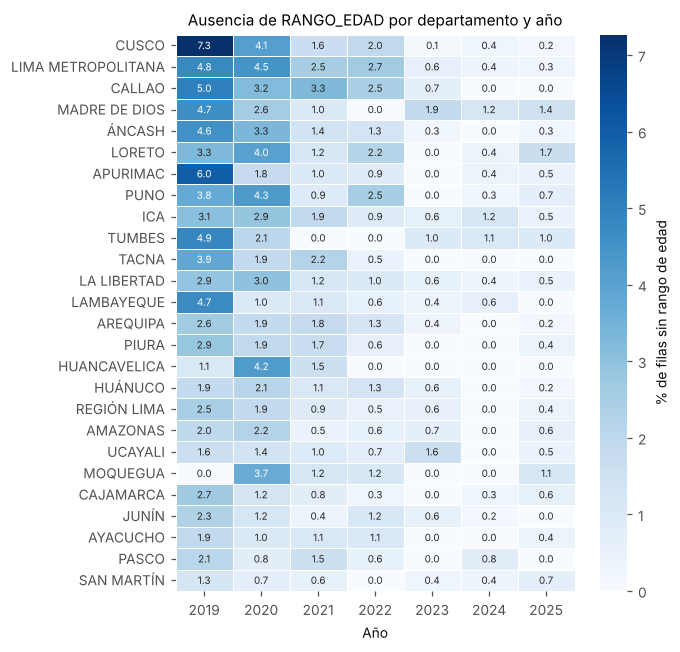

In [ ]:
heat = (df_clean.assign(sin_edad=df_clean["rango_edad"].isna())
        .pivot_table(index="dpto_hecho", columns="anio", values="sin_edad", aggfunc="mean") * 100)
fig, ax = plt.subplots(figsize=(6.3, 6))
sns.heatmap(heat.loc[pct_dep.index], cmap="Blues", annot=True, fmt=".1f", annot_kws={"size": 6.5},
            cbar_kws={"label": "% de filas sin rango de edad"}, linewidths=0.4, linecolor="white", ax=ax)
ax.set_xlabel("Año"); ax.set_ylabel(""); ax.set_title("Ausencia de RANGO_EDAD por departamento y año")
plt.tight_layout(); plt.show()

### 2.2 Decisión de limpieza
En el cuaderno de clase se imputó la media en atributos numéricos y se eliminaron las filas con categorías faltantes. Aquí **no**
eliminamos filas: la ausencia depende del año (eliminar afectaría sobre todo a 2019–2020) y las filas contienen personas reales que
cuentan para el objetivo. Para el análisis descriptivo, las ausencias se excluyen solo del cálculo de la variable afectada; para el
modelo, se representan con una categoría explícita «SIN DATO». No hay atributos numéricos con faltantes que imputar.

In [ ]:
df_model = df_clean.copy()
for col in ["sexo", "nacionalidad"]:
    df_model[col] = df_model[col].fillna("SIN DATO")
df_model["rango_edad"] = df_model["rango_edad"].cat.add_categories("SIN DATO").fillna("SIN DATO")
print("Faltantes tras la decisión (base para el modelo):", int(df_model[atributos].isna().sum().sum()))
print("Filas conservadas:", f"{len(df_model):,}", "| personas conservadas:", f"{df_model['cantidad'].sum():,}")

Faltantes tras la decisión (base para el modelo): 0
Filas conservadas: 77,331 | personas conservadas: 142,374


### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Faltan datos? ¿Dónde faltan, por qué faltan y qué hacemos con ellos?

**🛠️ ¿Cómo lo hicimos?**  
Buscamos celdas vacías y también valores «disfrazados» de dato, como «NO INDICA». Luego vimos si los vacíos se concentran en ciertos años o departamentos.

**📊 ¿Qué encontramos?**

- A primera vista Python decía que no faltaba nada, porque los vacíos estaban escritos como texto vacío y no como «dato faltante».
- Falta la edad de 1,357 personas (menos del 1 %) y el sexo de 90 personas (0.06 %).
- Los vacíos de edad se concentran en los primeros años: en 2019 faltaba la edad en 3.8 % de los registros y en 2023–2025 solo en 0.3–0.4 %.
- Ningún registro tiene dos datos faltantes al mismo tiempo.

**💡 ¿Qué significa?**  
Faltan pocos datos y cada vez faltan menos, lo que sugiere que la Policía ha mejorado su forma de registrar. No borramos esas filas, porque perderíamos sobre todo casos de 2019 y 2020. En su lugar las marcamos como «SIN DATO».

<details>
<summary><b>📐 Detalle técnico (cifras y pruebas estadísticas) — clic para ver</b></summary>

`isna()` devolvía 0 faltantes porque la ausencia está codificada como cadena vacía (83 en SEXO y 1,197 en RANGO_EDAD) y, de forma encubierta, como «NO INDICA» (3 en NACIONALIDAD); no hay «?». Tras normalizarlas, falta el rango de edad en 1.55 % de las filas (1,357 personas, 0.95 %) y el sexo en 0.11 % (90 personas). Ninguna fila carece de dos variables a la vez. La ausencia de edad depende claramente del año (χ²(6) = 806.6, p < .001, V = .102): pasa de 3.77 % en 2019 a 0.29–0.42 % en 2023–2025, y en menor grado del departamento (V = .046; máximos en Cusco y Lima Metropolitana, 2.27 %). La ausencia de sexo es mayor en 2019 (0.42 %) y no depende del departamento (p = .419). El patrón es compatible con un mecanismo MAR respecto del año (probable mejora del registro), no con MCAR. Por eso, a diferencia del cuaderno de clase, no eliminamos filas (perderíamos sobre todo casos de 2019–2020) y representamos la ausencia con la categoría «SIN DATO»; no hay atributos numéricos que imputar.

</details>

## Paso 3: Visualización de atributos numéricos
El único atributo numérico sustantivo es `CANTIDAD` (conteo por fila). Para el problema, la variable relevante es el número de
personas por **departamento-mes**, que construimos como un panel completo de 26 × 84 = 2,184 combinaciones (las combinaciones sin
registros valen cero: ausencia estructural, no dato perdido). Usamos diagramas de caja, histogramas, ECDF y la regla de Tukey
($L = Q_1 - 1.5\,IQR$, $U = Q_3 + 1.5\,IQR$), que **marca** observaciones potencialmente inusuales sin decidir que sean errores.

In [ ]:
dpto_prefijo = df_clean.groupby("dpto_hecho")["ubigeo_hecho"].agg(lambda s: set(s.str[:2]))
domain_checks = pd.DataFrame({
    "condicion": ["anio fuera de 2019–2025", "mes fuera de 1–12", "cantidad < 1", "ubigeo distinto de 6 dígitos",
                  "sexo fuera de {F, M} (sin NA)", "departamento con más de un prefijo UBIGEO", "meses sin ningún registro"],
    "violaciones": [int((~df_clean["anio"].between(2019, 2025)).sum()), int((~df_clean["mes"].between(1, 12)).sum()),
                    int((df_clean["cantidad"] < 1).sum()), int((~df_clean["ubigeo_hecho"].str.fullmatch(r"\d{6}")).sum()),
                    int((~df_clean["sexo"].dropna().isin(["F", "M"])).sum()), int((dpto_prefijo.apply(len) > 1).sum()),
                    84 - df_clean["periodo"].nunique()]})
display(domain_checks)
print("Prefijo UBIGEO compartido:", dpto_prefijo[dpto_prefijo.apply(lambda s: "15" in s)].index.tolist())

departamentos = sorted(df_clean["dpto_hecho"].unique())
periodos = pd.period_range("2019-01", "2025-12", freq="M")
panel = (df_clean.groupby(["dpto_hecho", "periodo"])["cantidad"].sum()
         .reindex(pd.MultiIndex.from_product([departamentos, periodos], names=["dpto_hecho", "periodo"]), fill_value=0)
         .rename("personas").reset_index())
panel["anio"] = panel["periodo"].dt.year; panel["mes"] = panel["periodo"].dt.month
print("Panel:", panel.shape, "| combinaciones con cero casos:", int((panel["personas"] == 0).sum()),
      "| suma = total:", panel["personas"].sum() == df_clean["cantidad"].sum())

,condicion,violaciones
0,anio fuera de 2019–2025,0
1,mes fuera de 1–12,0
2,cantidad < 1,0
3,ubigeo distinto de 6 dígitos,0
4,"sexo fuera de {F, M} (sin NA)",0
5,departamento con más de un prefijo UBIGEO,0
6,meses sin ningún registro,0


Prefijo UBIGEO compartido: ['LIMA METROPOLITANA', 'REGIÓN LIMA']
Panel: (2184, 5) | combinaciones con cero casos: 8 | suma = total: True


In [ ]:
def perfil(x: pd.Series) -> pd.Series:
    q1, q2, q3 = x.quantile([0.25, 0.5, 0.75]); iqr = q3 - q1; L, U = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series({"n": len(x), "media": x.mean(), "de": x.std(ddof=1), "min": x.min(), "q1": q1, "mediana": q2,
                      "q3": q3, "p99": x.quantile(0.99), "max": x.max(), "asimetria": stats.skew(x),
                      "curtosis_exceso": stats.kurtosis(x), "cerca_U_tukey": U,
                      "n_inusuales": int(((x < L) | (x > U)).sum()), "pct_inusuales": 100 * ((x < L) | (x > U)).mean()})

numeric_profile = pd.DataFrame({
    "cantidad_por_fila": perfil(df_clean["cantidad"].astype(float)),
    "personas_por_dpto_mes": perfil(panel["personas"].astype(float)),
    "log1p_personas_por_dpto_mes": perfil(np.log1p(panel["personas"].astype(float))),
}).T
display(numeric_profile.round(2))
print("Filas con cantidad = 1:", round(100 * (df_clean["cantidad"] == 1).mean(), 1), "%")

U = numeric_profile.loc["personas_por_dpto_mes", "cerca_U_tukey"]
print(f"Departamento-mes sobre la cerca superior (U = {U:.1f}):", panel["personas"].gt(U).sum(),
      panel.loc[panel["personas"] > U, "dpto_hecho"].value_counts().to_dict())
display(df_clean.nlargest(5, "cantidad")[["anio", "mes", "dpto_hecho", "dist_hecho", "sexo", "rango_edad", "nacionalidad", "cantidad"]])

,n,media,de,min,q1,mediana,q3,p99,max,asimetria,curtosis_exceso,cerca_U_tukey,n_inusuales,pct_inusuales
cantidad_por_fila,77331.0,1.84,2.07,1.0,1.00,1.00,2.00,11.00,53.00,5.69,54.80,3.50,7612.0,9.84
personas_por_dpto_mes,2184.0,65.19,106.12,0.0,21.75,40.00,67.00,604.34,910.00,4.64,23.11,134.88,105.0,4.81
log1p_personas_por_dpto_mes,2184.0,3.68,0.95,0.0,3.12,3.71,4.22,6.41,6.81,0.09,1.68,5.86,112.0,5.13


Filas con cantidad = 1: 67.6 %
Departamento-mes sobre la cerca superior (U = 134.9): 105 {'LIMA METROPOLITANA': 84, 'JUNÍN': 10, 'CUSCO': 9, 'LAMBAYEQUE': 2}


,anio,mes,dpto_hecho,dist_hecho,sexo,rango_edad,nacionalidad,cantidad
48551,2019,11,LIMA METROPOLITANA,SAN JUAN DE LURIGANCHO,F,12-17 AÑOS,PERÚ,53
39633,2019,12,LIMA METROPOLITANA,SAN JUAN DE LURIGANCHO,F,12-17 AÑOS,PERÚ,47
782,2020,2,LIMA METROPOLITANA,SAN JUAN DE LURIGANCHO,F,12-17 AÑOS,PERÚ,43
7951,2019,10,LIMA METROPOLITANA,ATE,F,12-17 AÑOS,PERÚ,43
1331,2019,1,LIMA METROPOLITANA,SAN JUAN DE LURIGANCHO,F,12-17 AÑOS,PERÚ,42


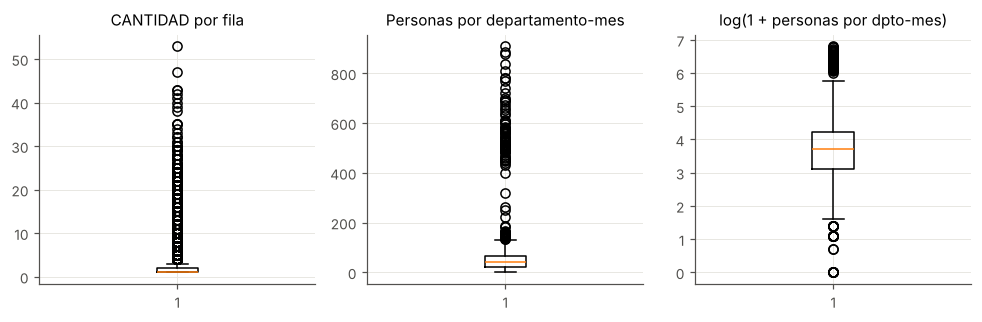

In [ ]:
# Diagramas de caja (dispersión y asimetría), como en el cuaderno de clase
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].boxplot(df_clean["cantidad"]); ax[0].set_title("CANTIDAD por fila")
ax[1].boxplot(panel["personas"]); ax[1].set_title("Personas por departamento-mes")
ax[2].boxplot(np.log1p(panel["personas"])); ax[2].set_title("log(1 + personas por dpto-mes)")
plt.tight_layout(); plt.show()

NameError: name 'panel' is not defined

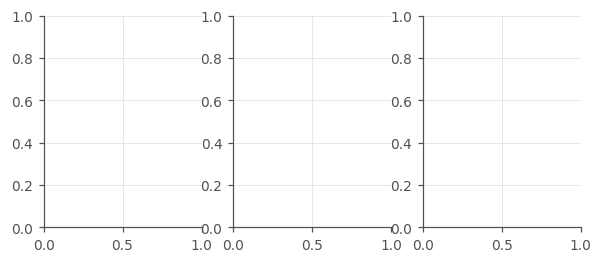

In [13]:
# Histogramas y ECDF (figura del manuscrito)
fig, axes = plt.subplots(1, 3, figsize=(6.3, 2.5))
y = panel["personas"]
axes[0].hist(y, bins=60, color=AZUL, edgecolor="white", linewidth=0.3)
axes[0].set_title("(a) Escala original"); axes[0].set_xlabel("Personas por departamento-mes"); axes[0].set_ylabel("Frecuencia")
axes[1].hist(np.log1p(y), bins=40, color=AZUL, edgecolor="white", linewidth=0.3)
axes[1].set_title("(b) Escala log(1 + y)"); axes[1].set_xlabel("log(1 + personas)")
for nombre, sub, color in [("2019–2023", panel.query("anio <= 2023")["personas"], AZUL),
                           ("2024–2025", panel.query("anio >= 2024")["personas"], NARANJA)]:
    xs = np.sort(sub); axes[2].step(xs, np.arange(1, len(xs) + 1) / len(xs), where="post", color=color, lw=1.4, label=nombre)
axes[2].set_xscale("symlog", linthresh=10); axes[2].set_title("(c) ECDF por periodo")
axes[2].set_xlabel("Personas (escala symlog)"); axes[2].set_ylabel("Proporción acumulada")
for u in (29, 59):
    axes[2].axvline(u, color=GRIS, lw=0.8, ls="--")
axes[2].legend(frameon=False, fontsize=7, loc="upper left")
plt.tight_layout(); fig.savefig(FIG_DIR / "figura4_distribucion_dpto_mes.png", bbox_inches="tight"); plt.show()

### 3.1 Diagrama de dispersión: población frente a número de casos
Como en el cuaderno de clase (edad frente a educación), exploramos la relación entre dos variables cuantitativas: la población de cada
departamento (proyección del INEI) y el número de personas reportadas. Lima Metropolitana = provincia 1501; Región Lima = departamento
15 menos la provincia 1501; Callao = 07. La unión se audita: 26 unidades y la suma coincide con el total nacional.

In [12]:
pop_raw = pd.read_excel(POP_FILE, header=None, dtype={0: str})
pop = pop_raw.iloc[6:, [0, 1] + list(range(3, 10))].copy()
pop.columns = ["ubigeo", "nombre"] + list(range(2019, 2026))
pop = pop.dropna(subset=["ubigeo"]); pop["ubigeo"] = pop["ubigeo"].str.strip()
pop = (pop[pop["ubigeo"].str.fullmatch(r"\d{6}")].set_index("ubigeo")[list(range(2019, 2026))]
       .apply(pd.to_numeric, errors="coerce"))       # algunas celdas traen notas de texto (distritos creados en 2021)

prefijo = df_clean.groupby("dpto_hecho")["ubigeo_hecho"].agg(lambda s: s.str[:2].iloc[0])
def poblacion_unidad(dpto):
    if dpto == "LIMA METROPOLITANA":
        return pop.loc["150100"]
    if dpto == "REGIÓN LIMA":
        return pop.loc["150000"] - pop.loc["150100"]
    return pop.loc[prefijo[dpto] + "0000"]
pop_unidad = pd.DataFrame({d: poblacion_unidad(d) for d in departamentos}).T
print("Unidades:", pop_unidad.shape[0], "| suma 2019 = Perú:", int(pop_unidad[2019].sum()) == int(pop.loc["000000", 2019]))

anual = df_clean.groupby(["dpto_hecho", "anio"])["cantidad"].sum().unstack()
territorio = pd.DataFrame({
    "personas": anual.sum(axis=1), "pct_del_total": 100 * anual.sum(axis=1) / anual.values.sum(),
    "poblacion_2025": pop_unidad[2025], "tasa_anual_100k": anual.sum(axis=1) / pop_unidad.sum(axis=1) * 1e5,
}).sort_values("tasa_anual_100k", ascending=False)
territorio["rank_conteo"] = territorio["personas"].rank(ascending=False).astype(int)
territorio["rank_tasa"] = territorio["tasa_anual_100k"].rank(ascending=False).astype(int)
tasa_nacional = anual.values.sum() / pop.loc["000000", list(range(2019, 2026))].sum() * 1e5
rho_pop = stats.spearmanr(territorio["poblacion_2025"], territorio["personas"])
rho_pop_tasa = stats.spearmanr(territorio["poblacion_2025"], territorio["tasa_anual_100k"])
print(f"Tasa nacional promedio: {tasa_nacional:.1f} por 100,000 hab./año")
print(f"Spearman población–conteo: ρ = {rho_pop.statistic:.3f} (p = {rho_pop.pvalue:.2e}) | "
      f"población–tasa: ρ = {rho_pop_tasa.statistic:.3f} (p = {rho_pop_tasa.pvalue:.3f})")

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.scatter(territorio["poblacion_2025"], territorio["personas"], color=AZUL, s=18)
for d in ["LIMA METROPOLITANA", "TACNA", "CAJAMARCA", "CUSCO", "MOQUEGUA"]:
    ax.annotate(nombre_bonito(d), (territorio.loc[d, "poblacion_2025"], territorio.loc[d, "personas"]),
                xytext=(4, 2), textcoords="offset points", fontsize=7, color="#52514e")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Población proyectada 2025 (escala log)"); ax.set_ylabel("Personas reportadas 2019–2025 (log)")
plt.tight_layout(); plt.show()
territorio.round(1)

NameError: name 'df_clean' is not defined

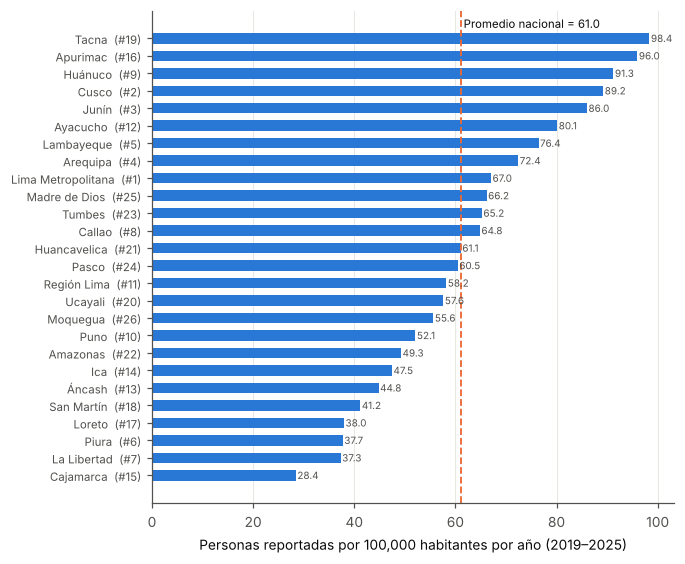

In [ ]:
orden = territorio.sort_values("tasa_anual_100k")
fig, ax = plt.subplots(figsize=(6.3, 5.2))
yy = np.arange(len(orden))
ax.barh(yy, orden["tasa_anual_100k"], color=AZUL, height=0.6)
ax.axvline(tasa_nacional, color=NARANJA, lw=1.2, ls="--")
ax.text(tasa_nacional + 0.6, len(orden) - 0.4, f"Promedio nacional = {tasa_nacional:.1f}", color="#0b0b0b", fontsize=7.5)
ax.set_yticks(yy, [f"{nombre_bonito(d)}  (#{r})" for d, r in zip(orden.index, orden["rank_conteo"])], fontsize=7.5)
for i, v in enumerate(orden["tasa_anual_100k"]):
    ax.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=6.5, color="#52514e")
ax.set_xlabel("Personas reportadas por 100,000 habitantes por año (2019–2025)")
ax.grid(axis="y", visible=False)
plt.tight_layout(); fig.savefig(FIG_DIR / "figura5_tasa_departamento.png", bbox_inches="tight"); plt.show()

### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Cómo se comportan los números? ¿Hay valores raros o imposibles?

**🛠️ ¿Cómo lo hicimos?**  
Revisamos los valores mínimos y máximos, hicimos histogramas y diagramas de caja, y comparamos el número de casos de cada departamento con su población.

**📊 ¿Qué encontramos?**

- No hay valores imposibles, como cantidades negativas o meses fuera de 1 a 12.
- En 2 de cada 3 filas la cantidad es 1 persona, aunque hay grupos grandes de hasta 53 personas, que son adolescentes de San Juan de Lurigancho y Ate.
- Un departamento tiene en promedio 65 casos al mes, pero la mitad de los meses tiene 40 o menos. Lima Metropolitana jala el promedio hacia arriba.
- Los departamentos con más gente tienen más casos. Por eso calculamos una tasa: casos por cada 100,000 habitantes.
- Con la tasa, el ranking cambia: Tacna es el departamento con más desapariciones en proporción a su población (98.4 por 100,000 al año), y Lima Metropolitana, primera en número de casos, baja al noveno lugar (67.0). El promedio nacional es 61.0.

**💡 ¿Qué significa?**  
Contar casos sin tener en cuenta la población engaña: un departamento grande siempre parecerá más peligroso. Para comparar departamentos de forma justa hay que usar tasas.

<details>
<summary><b>📐 Detalle técnico (cifras y pruebas estadísticas) — clic para ver</b></summary>

Las verificaciones de dominio no encontraron valores imposibles. CANTIDAD es muy asimétrica (asimetría 5.69): el 67.6 % de las filas vale 1 y la regla de Tukey marca 7,612 filas (9.84 %) por encima de 3.5; las mayores (42 a 53) son adolescentes mujeres de San Juan de Lurigancho y Ate en 2019–2020, valores plausibles que conservamos. En el panel de 2,184 departamento-mes, la media (65.2) supera ampliamente a la mediana (40) y los diagramas de caja muestran una cola derecha pesada (asimetría 4.64); los 105 valores sobre la cerca de Tukey (134.9) son los 84 meses de Lima Metropolitana, 10 de Junín, 9 de Cusco y 2 de Lambayeque: una subpoblación real de mayor escala, no errores. La escala log(1 + y) vuelve la distribución casi simétrica (asimetría 0.09). El diagrama de dispersión muestra que el número de casos crece casi en proporción a la población (ρ = .887), mientras que la tasa por habitante no se asocia significativamente con el tamaño (ρ = −.210, p = .303): la tasa nacional es 61.0 por 100,000 habitantes al año, Tacna lidera (98.4) y Lima Metropolitana, primera en casos, es novena en tasa (67.0). El tamaño de la población actúa como variable de confusión.

</details>

## Paso 4: Análisis de atributos categóricos
Gráficos de barras con la distribución de frecuencias de los atributos categóricos (ponderadas por personas) y perfil de
cardinalidad: la cantidad de niveles afecta la visualización, el One-Hot Encoding y el análisis por subgrupos.

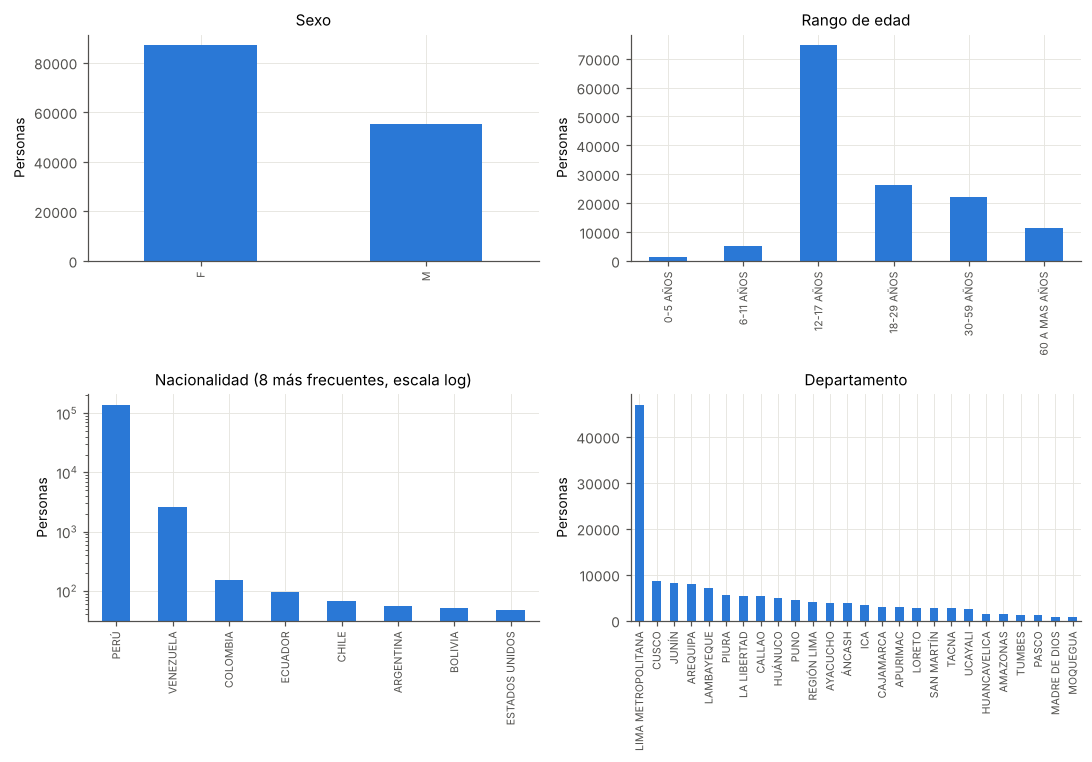

sexo {'F': 61.1, 'M': 38.9}
rango_edad {'0-5 AÑOS': 1.0, '6-11 AÑOS': 3.8, '12-17 AÑOS': 52.9, '18-29 AÑOS': 18.6, '30-59 AÑOS': 15.7, '60 A MAS AÑOS': 8.1}


In [ ]:
freq = {c: df_clean.groupby(c, observed=True)["cantidad"].sum() for c in ["sexo", "rango_edad", "nacionalidad", "dpto_hecho"]}
fig, ax = plt.subplots(2, 2, figsize=(10, 7))
freq["sexo"].plot(kind="bar", ax=ax[0, 0], color=AZUL); ax[0, 0].set_title("Sexo")
freq["rango_edad"].plot(kind="bar", ax=ax[0, 1], color=AZUL); ax[0, 1].set_title("Rango de edad")
freq["nacionalidad"].nlargest(8).plot(kind="bar", ax=ax[1, 0], color=AZUL, logy=True); ax[1, 0].set_title("Nacionalidad (8 más frecuentes, escala log)")
freq["dpto_hecho"].sort_values(ascending=False).plot(kind="bar", ax=ax[1, 1], color=AZUL); ax[1, 1].set_title("Departamento")
for a in ax.ravel():
    a.set_ylabel("Personas"); a.set_xlabel(""); a.tick_params(axis="x", labelsize=7)
plt.tight_layout(); plt.show()

for c in ["sexo", "rango_edad"]:
    print(c, (100 * freq[c] / freq[c].sum()).round(1).to_dict())

In [ ]:
categorical_columns = ["dpto_hecho", "prov_hecho", "dist_hecho", "ubigeo_hecho", "sexo", "rango_edad", "nacionalidad"]
filas = []
for column in categorical_columns:
    w = df_clean.groupby(column, dropna=True, observed=True)["cantidad"].sum().sort_values(ascending=False)
    share = w / w.sum()
    filas.append({"variable": column, "niveles_validos": len(w), "con_NA": bool(df_clean[column].isna().any()),
                  "nivel_mas_frecuente": w.index[0], "pct_personas_nivel_top": 100 * share.iloc[0],
                  "niveles_menores_al_1pct": int((share < 0.01).sum())})
categorical_profile = pd.DataFrame(filas)
display(categorical_profile.round(2))

nac = freq["nacionalidad"].sort_values(ascending=False)
print("Nacionalidades válidas:", len(nac), "| con 1 sola persona:", int((nac == 1).sum()),
      "| PERÚ:", round(100 * nac.iloc[0] / nac.sum(), 1), "% | VENEZUELA:", round(100 * nac["VENEZUELA"] / nac.sum(), 1), "%")
nombres = df_clean.drop_duplicates("ubigeo_hecho").groupby("dist_hecho")["ubigeo_hecho"].nunique()
print(f"Nombres de distrito: {df_clean['dist_hecho'].nunique():,} | UBIGEO: {df_clean['ubigeo_hecho'].nunique():,} | "
      f"nombres repetidos en >1 UBIGEO: {(nombres > 1).sum()}")
ubigeo_nombres = df_clean.groupby("ubigeo_hecho")["dist_hecho"].nunique()
display(df_clean[df_clean["ubigeo_hecho"].isin(ubigeo_nombres[ubigeo_nombres > 1].index)]
        .groupby(["ubigeo_hecho", "dist_hecho"]).size().to_frame("filas"))
print("Códigos de PUEBLO LIBRE (provincia de Lima):",
      sorted(df_clean.loc[(df_clean["dist_hecho"] == "PUEBLO LIBRE") & (df_clean["prov_hecho"] == "LIMA"), "ubigeo_hecho"].unique()))

# Agrupación de categorías raras de nacionalidad (decisión de representación)
df_model["nacionalidad_grupo"] = np.select([df_model["nacionalidad"] == "PERÚ", df_model["nacionalidad"] == "VENEZUELA",
                                            df_model["nacionalidad"] == "SIN DATO"], ["PERUANA", "VENEZOLANA", "SIN DATO"], "OTRAS")
print(df_model.groupby("nacionalidad_grupo")["cantidad"].sum().to_dict())

,variable,niveles_validos,con_NA,nivel_mas_frecuente,pct_personas_nivel_top,niveles_menores_al_1pct
0,dpto_hecho,26,False,LIMA METROPOLITANA,32.90,4
1,prov_hecho,195,False,LIMA,32.90,177
2,dist_hecho,1435,False,SAN JUAN DE LURIGANCHO,3.88,1414
3,ubigeo_hecho,1549,False,150132,3.88,1530
4,sexo,2,True,F,61.09,0
5,rango_edad,6,True,12-17 AÑOS,52.90,1
6,nacionalidad,59,True,PERÚ,97.73,57


Nacionalidades válidas: 59 | con 1 sola persona: 27 | PERÚ: 97.7 % | VENEZUELA: 1.8 %
Nombres de distrito: 1,435 | UBIGEO: 1,549 | nombres repetidos en >1 UBIGEO: 80


filas
ubigeo_hecho dist_hecho            
150121       MAGDALENA VIEJA      2
             PUEBLO LIBRE        68

Códigos de PUEBLO LIBRE (provincia de Lima): ['150121', '150144']


{'OTRAS': 670, 'PERUANA': 139139, 'SIN DATO': 3, 'VENEZOLANA': 2562}


### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Quiénes desaparecen? ¿Cómo se reparten los casos por sexo, edad, lugar y nacionalidad?

**🛠️ ¿Cómo lo hicimos?**  
Contamos personas (no filas) en cada categoría y lo mostramos en gráficos de barras.

**📊 ¿Qué encontramos?**

- 6 de cada 10 personas desaparecidas son mujeres (61.1 %).
- Más de la mitad son adolescentes de 12 a 17 años (52.9 % de quienes tienen la edad registrada).
- Lima Metropolitana concentra un tercio de los casos del país (32.9 %).
- Casi todas las personas son peruanas (97.7 %), y le siguen las venezolanas (1.8 %). Hay 57 nacionalidades con muy pocos casos y algunas mal escritas, como «MADRID», que es una ciudad.
- Hay 80 nombres de distrito que se repiten en distintos lugares del país (por ejemplo, hay varios «Santa Rosa»). Por eso usamos el código de ubicación y no el nombre.

**💡 ¿Qué significa?**  
El problema afecta sobre todo a mujeres adolescentes. Además, los datos tienen errores de escritura que hay que corregir y agrupar antes de usarlos en un modelo.

<details>
<summary><b>📐 Detalle técnico (cifras y pruebas estadísticas) — clic para ver</b></summary>

Ponderando por personas, el 61.1 % son mujeres y, entre quienes tienen la edad registrada, el 52.9 % tiene de 12 a 17 años (18.6 % de 18 a 29; 15.7 % de 30 a 59; 8.1 % de 60 a más; 3.8 % de 6 a 11 y 1.0 % de 0 a 5). Lima Metropolitana concentra el 32.9 % de los casos y cuatro departamentos tienen menos del 1 %. La nacionalidad está muy desbalanceada: Perú 97.7 %, Venezuela 1.8 % y 57 de las 59 nacionalidades válidas tienen menos del 1 % (27 con una sola persona), con valores irregulares como «MADRID», «TURKEY» o «TAIWAN (REPUBLICA DE CHIN» (truncado); por eso la agrupamos en peruana, venezolana, otras y «SIN DATO». En el territorio, 80 nombres de distrito se repiten en más de un UBIGEO y el código 150121 aparece con dos nombres (Pueblo Libre y Magdalena Vieja), mientras que Pueblo Libre de Lima usa los códigos 150121 y 150144: el UBIGEO, y no el nombre, debe ser la clave.

</details>

## Paso 5: Tablas cruzadas (análisis bivariado)
Tablas de contingencia entre pares de atributos, con proporciones condicionales, prueba de chi-cuadrado y *V* de Cramér (tamaño del
efecto). Incluimos el cruce de los atributos con el **nivel de riesgo** (variable objetivo) y la dependencia temporal.
**Asociación no es causalidad.**

sexo,F,M,pct_mujeres
rango_edad,,,
0-5 AÑOS,650,716,47.6
6-11 AÑOS,2034,3259,38.4
12-17 AÑOS,58891,15703,78.9
18-29 AÑOS,14136,12083,53.9
30-59 AÑOS,7091,14970,32.1
60 A MAS AÑOS,3347,8047,29.4


Sexo × rango de edad: χ²(5, N = 140,927) = 24,432.2, p = 0.00e+00, V = 0.416


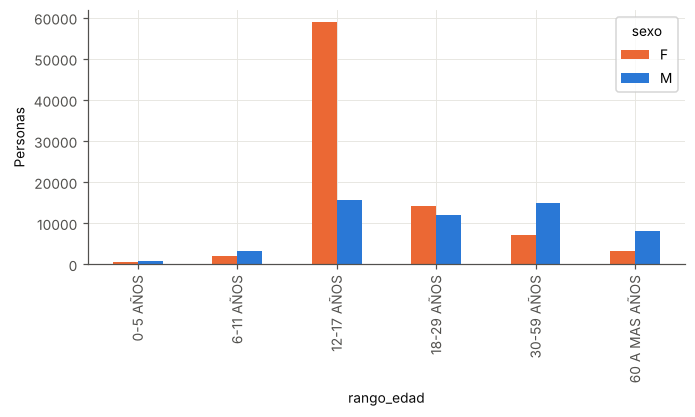

,Adulto,Menor,pct_menores
Peruana,58100,79746,57.9
Extranjera,1652,1516,47.9


Nacionalidad × minoría de edad: χ²(1, N = 141,014) = 126.8, p = 2.08e-29, V = 0.030


In [ ]:
validos = df_clean.dropna(subset=["sexo", "rango_edad"])
cross_tab_sexo_edad = validos.pivot_table(index="rango_edad", columns="sexo", values="cantidad", aggfunc="sum", observed=True)
cross_tab_sexo_edad["pct_mujeres"] = 100 * cross_tab_sexo_edad["F"] / cross_tab_sexo_edad[["F", "M"]].sum(axis=1)
display(cross_tab_sexo_edad.round(1))
chi2, dof, p, v_sexo_edad = cramers_v(cross_tab_sexo_edad[["F", "M"]])
print(f"Sexo × rango de edad: χ²({dof}, N = {int(cross_tab_sexo_edad[['F','M']].values.sum()):,}) = {chi2:,.1f}, p = {p:.2e}, V = {v_sexo_edad:.3f}")
cross_tab_sexo_edad[["F", "M"]].plot(kind="bar", color=[NARANJA, AZUL], figsize=(7, 3)); plt.ylabel("Personas"); plt.show()

tab_nac_edad = (df_clean.dropna(subset=["extranjero", "menor"])
                .pivot_table(index="extranjero", columns="menor", values="cantidad", aggfunc="sum"))
tab_nac_edad.index = ["Peruana", "Extranjera"]; tab_nac_edad.columns = ["Adulto", "Menor"]
tab_nac_edad["pct_menores"] = 100 * tab_nac_edad["Menor"] / tab_nac_edad[["Adulto", "Menor"]].sum(axis=1)
display(tab_nac_edad.round(1))
chi2_n, dof_n, p_n, v_nac_edad = cramers_v(tab_nac_edad[["Adulto", "Menor"]])
print(f"Nacionalidad × minoría de edad: χ²({dof_n}, N = {int(tab_nac_edad[['Adulto','Menor']].values.sum()):,}) = {chi2_n:,.1f}, p = {p_n:.2e}, V = {v_nac_edad:.3f}")

### 5.1 Nivel de riesgo (objetivo) por departamento y por año
Definimos aquí el objetivo con los umbrales del periodo de entrenamiento (29 y 59 personas; ver Paso 10) para cruzarlo con el
departamento y el año.

riesgo,Bajo,Medio,Alto,pct_alto
dpto_hecho,,,,
LIMA METROPOLITANA,0,0,84,100.000000
CUSCO,0,3,81,96.428571
AREQUIPA,0,3,81,96.428571
JUNÍN,1,3,80,95.238095
LAMBAYEQUE,0,5,79,94.047619
LA LIBERTAD,2,21,61,72.619048
PIURA,2,22,60,71.428571
CALLAO,1,35,48,57.142857
HUÁNUCO,2,45,37,44.047619


Departamento × nivel de riesgo: χ²(50) = 2,363.2, p = 0.00e+00, V = 0.736


riesgo,Bajo,Medio,Alto
anio,,,
2019,26.0,30.8,43.3
2020,38.5,33.3,28.2
2021,29.2,35.6,35.3
2022,40.4,31.7,27.9
2023,36.2,36.2,27.6
2024,40.1,28.5,31.4
2025,38.1,27.6,34.3


Año × nivel de riesgo: χ²(12) = 41.7, p = 0.0000, V = 0.098


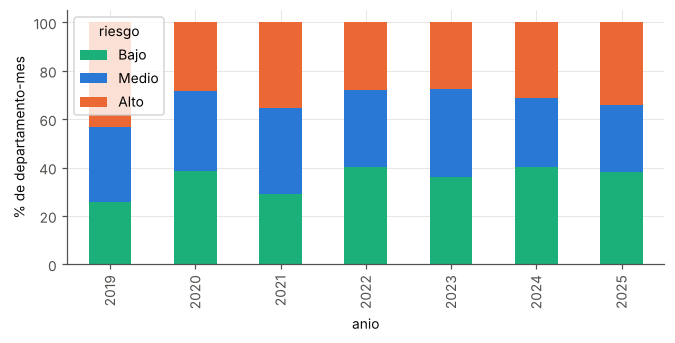

Siempre en la misma clase: ['LIMA METROPOLITANA', 'MADRE DE DIOS', 'MOQUEGUA'] | recorren las tres clases: 16


In [ ]:
UMBRALES_TRAIN = np.quantile(panel.loc[panel["anio"] <= 2023, "personas"], [1 / 3, 2 / 3])
etiquetar = lambda yv: pd.cut(yv, [-np.inf, UMBRALES_TRAIN[0], UMBRALES_TRAIN[1], np.inf], labels=["Bajo", "Medio", "Alto"])
panel["riesgo"] = etiquetar(panel["personas"])

cross_tab_dpto_riesgo = pd.crosstab(panel["dpto_hecho"], panel["riesgo"])
cross_tab_dpto_riesgo["pct_alto"] = 100 * cross_tab_dpto_riesgo["Alto"] / 84
display(cross_tab_dpto_riesgo.sort_values("pct_alto", ascending=False))
chi2_d, dof_d, p_d, v_dpto = cramers_v(cross_tab_dpto_riesgo[["Bajo", "Medio", "Alto"]])
print(f"Departamento × nivel de riesgo: χ²({dof_d}) = {chi2_d:,.1f}, p = {p_d:.2e}, V = {v_dpto:.3f}")

cross_tab_anio_riesgo = pd.crosstab(panel["anio"], panel["riesgo"], normalize="index") * 100
display(cross_tab_anio_riesgo.round(1))
chi2_a, dof_a, p_a, v_anio = cramers_v(pd.crosstab(panel["anio"], panel["riesgo"]))
print(f"Año × nivel de riesgo: χ²({dof_a}) = {chi2_a:.1f}, p = {p_a:.4f}, V = {v_anio:.3f}")
cross_tab_anio_riesgo.plot(kind="bar", stacked=True, color=[VERDEAGUA, AZUL, NARANJA], figsize=(7, 3)); plt.ylabel("% de departamento-mes"); plt.show()

clases_por_dpto = panel.groupby("dpto_hecho")["riesgo"].nunique()
print("Siempre en la misma clase:", clases_por_dpto[clases_por_dpto == 1].index.tolist(),
      "| recorren las tres clases:", int((clases_por_dpto == 3).sum()))

### 5.2 Dependencia temporal: estacionalidad y autocorrelación

mes,1,2,3,4,5,6,7,8,9,10,11,12
mean,1.024,0.985,1.013,0.955,0.989,0.920,0.985,1.009,0.989,0.995,1.036,1.099
min,0.703,0.816,0.935,0.910,0.928,0.874,0.910,0.914,0.950,0.920,1.015,0.917
max,1.250,1.059,1.067,1.071,1.118,1.001,1.046,1.080,1.023,1.044,1.060,1.494


Kruskal–Wallis entre meses (sin 2020): H(11) = 17.87, p = 0.0848
Mínimo y máximo mensual: 2020-04 643 | 2020-02 2725


,autocorrelación
lag_1,0.499
lag_2,0.326
lag_3,0.317
lag_12,-0.009


Spearman Y_t vs Y_(t-1) dentro de cada departamento: mediana = 0.41 (rango 0.16 a 0.67); panel completo: 0.900


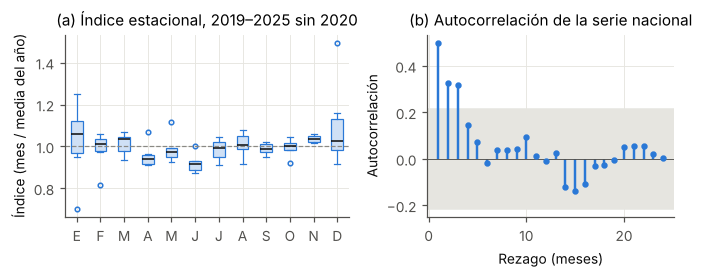

In [ ]:
nacional = df_clean.groupby("periodo")["cantidad"].sum()
serie = nacional.to_frame("personas"); serie["anio"] = serie.index.year; serie["mes"] = serie.index.month
serie["indice"] = serie["personas"] / serie.groupby("anio")["personas"].transform("mean")   # mes / media de su año
sin2020 = serie.query("anio != 2020")
display(sin2020.groupby("mes")["indice"].agg(["mean", "min", "max"]).round(3).T)
kw = stats.kruskal(*[g["indice"].values for _, g in sin2020.groupby("mes")])
print(f"Kruskal–Wallis entre meses (sin 2020): H(11) = {kw.statistic:.2f}, p = {kw.pvalue:.4f}")
print("Mínimo y máximo mensual:", nacional.idxmin(), int(nacional.min()), "|", nacional.idxmax(), int(nacional.max()))

def acf(x, lag):
    x = np.asarray(x, float) - np.mean(x)
    return np.sum(x[lag:] * x[:-lag]) / np.sum(x * x)
display(pd.Series({f"lag_{k}": acf(nacional.values, k) for k in (1, 2, 3, 12)}, name="autocorrelación").round(3).to_frame())

panel = panel.sort_values(["dpto_hecho", "periodo"])
panel["personas_lag1"] = panel.groupby("dpto_hecho")["personas"].shift(1)
rho_intra = panel.dropna(subset=["personas_lag1"]).groupby("dpto_hecho").apply(
    lambda g: stats.spearmanr(g["personas"], g["personas_lag1"]).statistic)
print(f"Spearman Y_t vs Y_(t-1) dentro de cada departamento: mediana = {rho_intra.median():.2f} "
      f"(rango {rho_intra.min():.2f} a {rho_intra.max():.2f}); panel completo: "
      f"{stats.spearmanr(panel['personas'][1:], panel['personas_lag1'][1:], nan_policy='omit').statistic:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(6.3, 2.6), gridspec_kw={"width_ratios": [1.15, 1]})
data_box = [sin2020.query("mes == @m")["indice"].values for m in range(1, 13)]
axes[0].boxplot(data_box, widths=0.5, patch_artist=True, medianprops={"color": "#0b0b0b", "lw": 1},
                boxprops={"facecolor": "#cfe0f5", "edgecolor": AZUL, "lw": 0.8}, whiskerprops={"color": AZUL, "lw": 0.8},
                capprops={"color": AZUL, "lw": 0.8}, flierprops={"marker": "o", "markersize": 3, "markeredgecolor": AZUL})
axes[0].axhline(1, color=GRIS, lw=0.8, ls="--")
axes[0].set_xticks(range(1, 13), ["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
axes[0].set_ylabel("Índice (mes / media del año)"); axes[0].set_title("(a) Índice estacional, 2019–2025 sin 2020")
lags = np.arange(1, 25)
axes[1].vlines(lags, 0, [acf(nacional.values, k) for k in lags], color=AZUL, lw=1.6)
axes[1].scatter(lags, [acf(nacional.values, k) for k in lags], color=AZUL, s=10, zorder=3)
banda = 1.96 / np.sqrt(len(nacional)); axes[1].axhspan(-banda, banda, color="#e6e5e0", zorder=0)
axes[1].axhline(0, color="#52514e", lw=0.6)
axes[1].set_xlabel("Rezago (meses)"); axes[1].set_ylabel("Autocorrelación"); axes[1].set_title("(b) Autocorrelación de la serie nacional")
plt.tight_layout(); fig.savefig(FIG_DIR / "figura6_temporalidad.png", bbox_inches="tight"); plt.show()

### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Unas variables se relacionan con otras? ¿Influye el mes o el año?

**🛠️ ¿Cómo lo hicimos?**  
Cruzamos variables en tablas, como sexo con edad o departamento con nivel de riesgo, y usamos pruebas estadísticas para saber si la relación es real o casualidad. También revisamos la evolución mes a mes.

**📊 ¿Qué encontramos?**

- Sexo y edad están muy relacionados: entre los adolescentes de 12 a 17 años, 8 de cada 10 son mujeres. Entre los adultos de 30 a 59 años, solo 3 de cada 10 lo son.
- El departamento casi decide por sí solo el nivel de riesgo. Lima Metropolitana estuvo en nivel ALTO los 84 meses, y Moquegua y Madre de Dios en nivel BAJO los 84 meses.
- La pandemia se nota claramente: en febrero de 2020 hubo 2,725 casos y en abril de 2020, durante la cuarentena, solo 643.
- No hay meses del año con claramente más casos que otros. Diciembre sale un poco más alto, pero la diferencia no es significativa.
- Lo que pasa en un mes se parece a lo que pasó el mes anterior.

**💡 ¿Qué significa?**  
Como cada mes depende del anterior, para probar el modelo hay que usar el pasado para predecir el futuro: entrenar con 2019–2023 y evaluar con 2024–2025. No sirve mezclar los meses al azar.

<details>
<summary><b>📐 Detalle técnico (cifras y pruebas estadísticas) — clic para ver</b></summary>

El sexo y la edad están fuertemente asociados (χ²(5, N = 140,927) = 24,432.2, p < .001, V = .416): las mujeres son el 78.9 % entre los 12 y 17 años, pero solo el 32.1 % entre 30 y 59 años y el 29.4 % desde los 60. Entre personas extranjeras hay menos menores (47.9 % frente a 57.9 %), pero el efecto es despreciable (V = .030): con N grande, significativo no equivale a relevante. El cruce con el objetivo muestra que el departamento casi determina el nivel de riesgo (V = .736): Lima Metropolitana está en nivel alto los 84 meses y Moquegua y Madre de Dios en nivel bajo los 84 meses, mientras que 16 departamentos recorren los tres niveles. La asociación con el año es débil (V = .098), con más meses de nivel alto en 2019 (43.3 %). En el tiempo, la serie nacional cae a 643 personas en abril de 2020 (cuarentena) desde 2,725 en febrero de 2020; sin 2020, diciembre (1.10) y noviembre (1.04) están algo por encima del promedio y junio (0.92) por debajo, pero las diferencias entre meses no son significativas (H(11) = 17.87, p = .085). La autocorrelación es .50 a un mes y casi nula a 12 meses (−.01): memoria de corto plazo sin ciclo anual, lo que exige una partición temporal.

</details>

## Paso 6: Análisis de un segmento específico de la población
Caracterizamos el segmento más numeroso: **mujeres adolescentes de 12 a 17 años**. Creamos el subconjunto y describimos su peso,
su evolución, su distribución territorial y su nacionalidad, comparándolo con el resto de personas reportadas.

In [ ]:
segmento_df = df_clean[(df_clean["sexo"] == "F") & (df_clean["rango_edad"] == "12-17 AÑOS")]
resto_df = df_clean.drop(segmento_df.index)
total = df_clean["cantidad"].sum()
print(f"Personas en el segmento: {segmento_df['cantidad'].sum():,} ({100 * segmento_df['cantidad'].sum() / total:.1f} % del total) "
      f"en {len(segmento_df):,} filas")
segmento_df.describe(include="all").T

Personas en el segmento: 58,891 (41.4 % del total) en 22,799 filas


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
anio,22799.0,NaN,NaN,NaN,2021.9239,1.996608,2019.0,2020.0,2022.0,2024.0,2025.0
mes,22799.0,NaN,NaN,NaN,6.626124,3.479119,1.0,4.0,7.0,10.0,12.0
ubigeo_hecho,22799,1344,150135,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dpto_hecho,22799,26,LIMA METROPOLITANA,3007,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prov_hecho,22799,193,LIMA,3007,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dist_hecho,22799,1247,LA VICTORIA,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sexo,22799,1,F,22799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rango_edad,22799,1,12-17 AÑOS,22799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nacionalidad,22799,13,PERÚ,21922,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad,22799.0,NaN,NaN,NaN,2.583052,3.21494,1.0,1.0,1.0,3.0,53.0


,% del total anual
anio,
2019,43.5
2020,43.5
2021,45.7
2022,41.1
2023,39.3
2024,38.3
2025,37.6


Peso del segmento × año: χ²(6) = 469.8, p = 2.71e-98, V = 0.057
Menor peso: {'LIMA METROPOLITANA': 34.4, 'PUNO': 35.1, 'AREQUIPA': 35.7} | mayor peso: {'LORETO': 53.2, 'TUMBES': 53.4, 'CAJAMARCA': 54.1}
Spearman peso del segmento–tasa por 100,000 (26 dptos): ρ = -0.363, p = 0.069
Distritos con más casos del segmento: {'SAN JUAN DE LURIGANCHO': 2045, 'ATE': 1308, 'CALLAO': 1195, 'SAN MARTIN DE PORRES': 1052, 'CHICLAYO': 998}
% venezolanas en el segmento: 1.5 | en el resto: 2.0
Desviación estándar del índice mensual — segmento: 0.052 | resto: 0.044


mes,1,2,3,4,5,6,7,8,9,10,11,12
segmento,1.047,1.015,0.967,0.936,0.979,0.916,0.984,1.008,0.991,1.011,1.030,1.115
resto,1.012,0.971,1.041,0.961,0.990,0.918,0.987,1.007,0.991,0.990,1.042,1.092


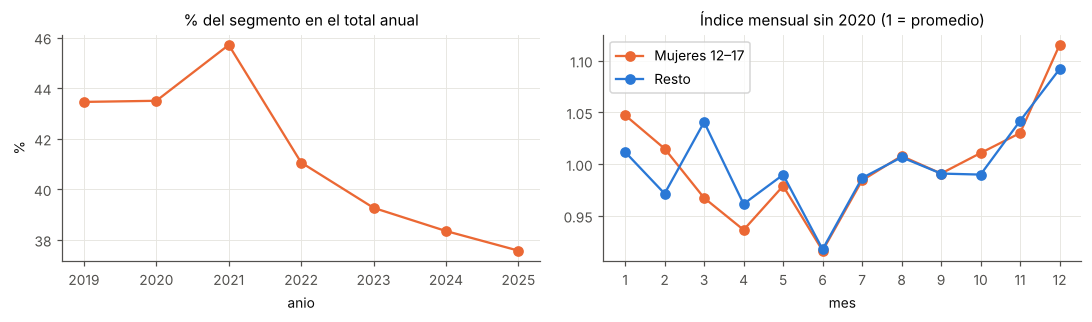

In [ ]:
peso_anual = 100 * segmento_df.groupby("anio")["cantidad"].sum() / df_clean.groupby("anio")["cantidad"].sum()
display(peso_anual.round(1).to_frame("% del total anual"))
chi2_s, dof_s, p_s, v_seg_anio = cramers_v(pd.DataFrame({"seg": segmento_df.groupby("anio")["cantidad"].sum(),
                                                         "resto": resto_df.groupby("anio")["cantidad"].sum()}))
print(f"Peso del segmento × año: χ²({dof_s}) = {chi2_s:.1f}, p = {p_s:.2e}, V = {v_seg_anio:.3f}")

peso_dpto = (100 * segmento_df.groupby("dpto_hecho")["cantidad"].sum() / df_clean.groupby("dpto_hecho")["cantidad"].sum()).sort_values()
print("Menor peso:", peso_dpto.head(3).round(1).to_dict(), "| mayor peso:", peso_dpto.tail(3).round(1).to_dict())
rho_seg_tasa = stats.spearmanr(peso_dpto.loc[territorio.index], territorio["tasa_anual_100k"])
print(f"Spearman peso del segmento–tasa por 100,000 (26 dptos): ρ = {rho_seg_tasa.statistic:.3f}, p = {rho_seg_tasa.pvalue:.3f}")
print("Distritos con más casos del segmento:", segmento_df.groupby("dist_hecho")["cantidad"].sum().nlargest(5).to_dict())
pct_ven_seg = 100 * segmento_df.loc[segmento_df["nacionalidad"] == "VENEZUELA", "cantidad"].sum() / segmento_df["cantidad"].sum()
pct_ven_resto = 100 * resto_df.loc[resto_df["nacionalidad"] == "VENEZUELA", "cantidad"].sum() / resto_df["cantidad"].sum()
print(f"% venezolanas en el segmento: {pct_ven_seg:.1f} | en el resto: {pct_ven_resto:.1f}")

# Índice mensual sin 2020 (cuarentena), igual que el índice nacional del Paso 5
idx_seg = segmento_df.query("anio != 2020").groupby("mes")["cantidad"].sum(); idx_seg = idx_seg / idx_seg.mean()
idx_resto = resto_df.query("anio != 2020").groupby("mes")["cantidad"].sum(); idx_resto = idx_resto / idx_resto.mean()
print("Desviación estándar del índice mensual — segmento:", round(idx_seg.std(), 3), "| resto:", round(idx_resto.std(), 3))
display(pd.DataFrame({"segmento": idx_seg, "resto": idx_resto}).round(3).T)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
peso_anual.plot(ax=ax[0], marker="o", color=NARANJA); ax[0].set_title("% del segmento en el total anual"); ax[0].set_ylabel("%")
pd.DataFrame({"Mujeres 12–17": idx_seg, "Resto": idx_resto}).plot(ax=ax[1], color=[NARANJA, AZUL], marker="o")
ax[1].set_title("Índice mensual sin 2020 (1 = promedio)"); ax[1].set_xticks(range(1, 13))
plt.tight_layout(); plt.show()

### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Qué pasa con el grupo más afectado: las mujeres de 12 a 17 años?

**🛠️ ¿Cómo lo hicimos?**  
Separamos solo a las adolescentes mujeres y analizamos cuántas son, cómo cambian por año y en qué lugares se concentran.

**📊 ¿Qué encontramos?**

- Son 58,891 personas: 4 de cada 10 desaparecidos del país (41.4 %).
- Su peso viene bajando: eran el 45.7 % en 2021 y el 37.6 % en 2025.
- En Cajamarca son más de la mitad de los casos (54.1 %), y en Lima Metropolitana, un tercio (34.4 %).
- Los distritos con más casos de adolescentes son San Juan de Lurigancho (2,045), Ate (1,308), Callao (1,195), San Martín de Porres (1,052) y Chiclayo (998).

**💡 ¿Qué significa?**  
Si hubiera que priorizar la prevención, este grupo y esos distritos serían el punto de partida.

<details>
<summary><b>📐 Detalle técnico (cifras y pruebas estadísticas) — clic para ver</b></summary>

El segmento de mujeres de 12 a 17 años reúne 58,891 personas, el 41.4 % de todos los reportes. Su peso es estadísticamente distinto entre años (χ²(6) = 469.8, p < .001, V = .057) y muestra una tendencia descendente: 43.5 % en 2019, 45.7 % en 2021 y 37.6 % en 2025. Entre departamentos varía de 34.4 % en Lima Metropolitana a 54.1 % en Cajamarca, y su asociación con la tasa por habitante es negativa pero no significativa (ρ = −.363, p = .069). Los distritos con más casos del segmento son San Juan de Lurigancho (2,045), Ate (1,308), Callao (1,195), San Martín de Porres (1,052) y Chiclayo (998). Las venezolanas son el 1.5 % del segmento (2.0 % en el resto). Sin 2020, su patrón mensual es parecido al del resto: máximo en diciembre (1.12) y enero (1.05) y mínimos en junio (0.92) y abril (0.94), con una variación entre meses apenas mayor (DE del índice .052 frente a .044); con 2020 incluido el patrón parecería más marcado, pero ese efecto proviene de la cuarentena.

</details>

## Paso 7: Comparación entre las categorías del objetivo
Comparamos los departamento-mes de nivel **Bajo**, **Medio** y **Alto** (periodo de entrenamiento 2019–2023) en sus características:
número de personas, composición demográfica del mes (proporción de mujeres, de menores y de extranjeros), tasa por habitante,
mes y año. Creamos subconjuntos por clase y comparamos sus estadísticos y distribuciones.

In [ ]:
comp_mes = (df_clean.groupby(["dpto_hecho", "periodo"]).apply(lambda g: pd.Series({
    "prop_mujeres": (g["cantidad"] * (g["sexo"] == "F")).sum() / g.loc[g["sexo"].notna(), "cantidad"].sum(),
    "prop_menores": (g["cantidad"] * g["menor"].fillna(0)).sum() / g.loc[g["menor"].notna(), "cantidad"].sum(),
    "prop_extranjeros": (g["cantidad"] * g["extranjero"].fillna(0)).sum() / g.loc[g["extranjero"].notna(), "cantidad"].sum(),
})).reset_index())
panel = panel.merge(comp_mes, on=["dpto_hecho", "periodo"], how="left")
pop_largo = pop_unidad.stack().rename("poblacion").rename_axis(["dpto_hecho", "anio"]).reset_index()
panel = panel.merge(pop_largo, on=["dpto_hecho", "anio"], how="left")
panel["tasa_mensual_100k"] = panel["personas"] / panel["poblacion"] * 1e5

train_panel = panel[panel["anio"] <= 2023]
variables_clase = ["personas", "tasa_mensual_100k", "prop_mujeres", "prop_menores", "prop_extranjeros", "mes"]
bajo_df, medio_df, alto_df = (train_panel[train_panel["riesgo"] == c] for c in ["Bajo", "Medio", "Alto"])
print("n por clase:", len(bajo_df), len(medio_df), len(alto_df))
comparacion_clases = train_panel.groupby("riesgo", observed=True)[variables_clase].median().T
comparacion_clases["Kruskal_H"] = [stats.kruskal(*[g[v].dropna() for _, g in train_panel.groupby("riesgo", observed=True)]).statistic for v in variables_clase]
comparacion_clases["p_valor"] = [stats.kruskal(*[g[v].dropna() for _, g in train_panel.groupby("riesgo", observed=True)]).pvalue for v in variables_clase]
display(comparacion_clases.round(3))
display(train_panel.groupby("riesgo", observed=True)[variables_clase].mean().T.round(3))

n por clase: 531 523 506


riesgo,Bajo,Medio,Alto,Kruskal_H,p_valor
personas,16.000,42.000,85.000,1385.745,0.000
tasa_mensual_100k,4.081,4.322,6.203,231.131,0.000
prop_mujeres,0.643,0.656,0.629,12.402,0.002
prop_menores,0.625,0.644,0.620,15.101,0.001
prop_extranjeros,0.000,0.000,0.013,129.911,0.000
mes,6.000,7.000,7.000,1.858,0.395


riesgo,Bajo,Medio,Alto
personas,16.241,42.920,140.190
tasa_mensual_100k,4.295,5.197,6.675
prop_mujeres,0.645,0.654,0.635
prop_menores,0.625,0.636,0.611
prop_extranjeros,0.016,0.012,0.017
mes,6.358,6.499,6.650


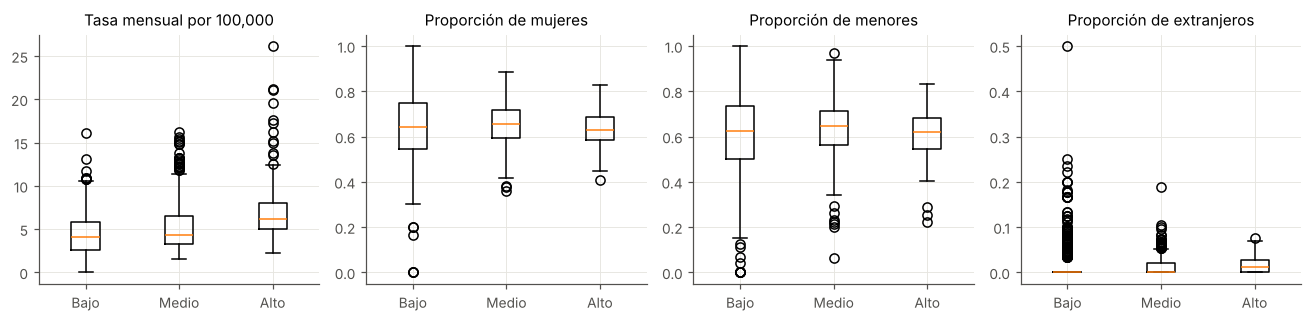

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for a, v, t in zip(ax, ["tasa_mensual_100k", "prop_mujeres", "prop_menores", "prop_extranjeros"],
                   ["Tasa mensual por 100,000", "Proporción de mujeres", "Proporción de menores", "Proporción de extranjeros"]):
    a.boxplot([g[v].dropna() for _, g in train_panel.groupby("riesgo", observed=True)], tick_labels=["Bajo", "Medio", "Alto"])
    a.set_title(t)
plt.tight_layout(); plt.show()

### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿En qué se diferencian los meses de riesgo BAJO, MEDIO y ALTO?

**🛠️ ¿Cómo lo hicimos?**  
Clasificamos cada departamento en cada mes según el número de desaparecidos. Luego comparamos las tres clases solo con los datos de entrenamiento (2019–2023).

**📊 ¿Qué encontramos?**

- Las tres clases tienen casi el mismo tamaño (531, 523 y 506 meses), así que están balanceadas.
- Además de tener más casos, los meses de riesgo ALTO también tienen una tasa mayor por habitante.
- El porcentaje de mujeres, de menores o de extranjeros cambia muy poco entre clases.
- El mes del año no ayuda a distinguir las clases.

**💡 ¿Qué significa?**  
El nivel de riesgo depende sobre todo del lugar y del tamaño de la población, y muy poco del perfil de las personas o de la época del año.

<details>
<summary><b>📐 Detalle técnico (cifras y pruebas estadísticas) — clic para ver</b></summary>

En el entrenamiento (531 Bajo, 523 Medio y 506 Alto), las clases difieren, como es lógico, en el número de personas (medianas 16, 42 y 85), pero también en la tasa mensual por 100,000 habitantes (medianas 4.08, 4.32 y 6.20; H = 231.1, p < .001): los meses de nivel alto no son solo los de departamentos grandes, sino también los de mayor incidencia relativa. La composición demográfica difiere poco: la proporción de mujeres (medianas .643, .656 y .629) y la de menores (.625, .644 y .620) son algo menores en el nivel alto, y la mediana de la proporción de extranjeros es mayor (.013 frente a 0), aunque las medias son parecidas (.016, .012 y .017), porque en los meses con pocos casos la proporción suele ser 0 o muy alta. El mes no distingue las clases (H = 1.86, p = .395), lo que anticipa que la codificación cíclica del mes aportará poco al modelo.

</details>

## Paso 8: One-Hot Encoding para aprendizaje automático
La mayoría de algoritmos solo acepta entradas numéricas. Convertimos los atributos nominales en variables binarias (*dummies*) y
comparamos con `LabelEncoder`, que asigna enteros arbitrarios. **Atención:** explosión de columnas cuando la cardinalidad es alta.

In [ ]:
from pandas.api.types import is_numeric_dtype
def resumen_columnas(frame: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "tipo": frame.dtypes.apply(lambda t: "numérica" if is_numeric_dtype(t) else "categórica"),
        "n_unique": frame.nunique(dropna=False), "n_missing": frame.isnull().sum(),
        "ejemplos": frame.apply(lambda s: list(s.dropna().unique()[:4])),
    })
display(resumen_columnas(df_model[atributos + ["cantidad"]]))

columnas_one_hot = pd.Series({c: df_model[c].nunique() for c in ["dpto_hecho", "prov_hecho", "ubigeo_hecho", "nacionalidad",
                                                                  "nacionalidad_grupo", "sexo", "rango_edad"]}, name="columnas_dummies")
display(columnas_one_hot.to_frame())

# Matriz numérica del panel departamento-mes (unidad del modelo)
panel_modelo = panel[["dpto_hecho", "anio", "mes", "personas", "riesgo"]].copy()
std_format_df = pd.get_dummies(panel_modelo, columns=["dpto_hecho", "riesgo"], dtype=int)
print("Dimensión antes:", panel_modelo.shape, "→ después del One-Hot:", std_format_df.shape)
display(std_format_df.head())
std_format_df.to_csv(OUT_DIR / "panel_dpto_mes_numerico.csv", index=False)

,dtype,tipo,n_unique,n_missing,ejemplos
anio,int16,numérica,7,0,"[2019, 2025, 2020, 2024]"
mes,int8,numérica,12,0,"[5, 3, 11, 2]"
ubigeo_hecho,string,categórica,1549,0,"[150120, 200304, 120421, 200115]"
dpto_hecho,string,categórica,26,0,"[LIMA METROPOLITANA, PIURA, JUNÍN, ÁNCASH]"
prov_hecho,string,categórica,195,0,"[LIMA, HUANCABAMBA, JAUJA, PIURA]"
dist_hecho,string,categórica,1435,0,"[MAGDALENA DEL MAR, HUARMACA, MUQUIYAUYO, 26 D..."
sexo,string,categórica,3,0,"[M, F, SIN DATO]"
rango_edad,category,categórica,7,0,"[60 A MAS AÑOS, 12-17 AÑOS, 6-11 AÑOS, 18-29 A..."
nacionalidad,string,categórica,60,0,"[PERÚ, VENEZUELA, BOLIVIA, COLOMBIA]"
cantidad,int32,numérica,43,0,"[1, 3, 2, 4]"


,columnas_dummies
dpto_hecho,26
prov_hecho,195
ubigeo_hecho,1549
nacionalidad,60
nacionalidad_grupo,4
sexo,3
rango_edad,7


Dimensión antes: (2184, 5) → después del One-Hot: (2184, 32)


,anio,mes,personas,dpto_hecho_AMAZONAS,dpto_hecho_APURIMAC,dpto_hecho_AREQUIPA,dpto_hecho_AYACUCHO,dpto_hecho_CAJAMARCA,dpto_hecho_CALLAO,dpto_hecho_CUSCO,dpto_hecho_HUANCAVELICA,dpto_hecho_HUÁNUCO,dpto_hecho_ICA,dpto_hecho_JUNÍN,dpto_hecho_LA LIBERTAD,dpto_hecho_LAMBAYEQUE,dpto_hecho_LIMA METROPOLITANA,dpto_hecho_LORETO,dpto_hecho_MADRE DE DIOS,dpto_hecho_MOQUEGUA,dpto_hecho_PASCO,dpto_hecho_PIURA,dpto_hecho_PUNO,dpto_hecho_REGIÓN LIMA,dpto_hecho_SAN MARTÍN,dpto_hecho_TACNA,dpto_hecho_TUMBES,dpto_hecho_UCAYALI,dpto_hecho_ÁNCASH,riesgo_Bajo,riesgo_Medio,riesgo_Alto
0,2019,1,19,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,2019,2,24,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,2019,3,37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,2019,4,17,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,2019,5,21,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [ ]:
# Diferencia con Label Encoding: introduce un orden artificial (alfabético) en una variable nominal
le_dpto = LabelEncoder().fit(panel_modelo["dpto_hecho"])
mapa = pd.Series(range(len(le_dpto.classes_)), index=le_dpto.classes_, name="codigo")
display(mapa.head(8).to_frame())
print("Con LabelEncoder, 'AREQUIPA' (2) quedaría 'entre' 'APURIMAC' (1) y 'AYACUCHO' (3) y Lima Metropolitana (13) "
      "estaría 'más cerca' de Lambayeque (12) que de Callao (5): distancias sin sentido para una variable nominal.")

# Para la edad (ordinal) sí tiene sentido un código que respete el orden
codigo_edad = {c: i for i, c in enumerate(orden_edad)}
print("Codificación ordinal de RANGO_EDAD:", codigo_edad)

,codigo
AMAZONAS,0
APURIMAC,1
AREQUIPA,2
AYACUCHO,3
CAJAMARCA,4
CALLAO,5
CUSCO,6
HUANCAVELICA,7


Con LabelEncoder, 'AREQUIPA' (2) quedaría 'entre' 'APURIMAC' (1) y 'AYACUCHO' (3) y Lima Metropolitana (13) estaría 'más cerca' de Lambayeque (12) que de Callao (5): distancias sin sentido para una variable nominal.
Codificación ordinal de RANGO_EDAD: {'0-5 AÑOS': 0, '6-11 AÑOS': 1, '12-17 AÑOS': 2, '18-29 AÑOS': 3, '30-59 AÑOS': 4, '60 A MAS AÑOS': 5}


### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Cómo convertimos palabras (como «Cusco» o «Piura») en números que un modelo pueda entender?

**🛠️ ¿Cómo lo hicimos?**  
Usamos One-Hot Encoding: por cada departamento se crea una columna de «sí» (1) o «no» (0). Así, un mes de Cusco tiene un 1 en la columna Cusco y 0 en las demás.

**📊 ¿Qué encontramos?**

- La tabla pasa de 5 a 32 columnas: 26 de departamentos y 3 de niveles de riesgo.
- Si lo hubiéramos hecho por distrito, habríamos creado más de 1,500 columnas casi vacías.
- La otra opción, LabelEncoder, pone números en orden alfabético (Amazonas = 0, Apurímac = 1…). Eso le haría creer al modelo que Apurímac es «mayor» que Amazonas, y eso no tiene sentido.

**💡 ¿Qué significa?**  
One-Hot es la forma correcta de convertir categorías sin un orden natural. Solo la edad, que sí tiene un orden, puede numerarse de menor a mayor.

<details>
<summary><b>📐 Detalle técnico (cifras y pruebas estadísticas) — clic para ver</b></summary>

La matriz del panel pasa de 5 a 32 columnas con `get_dummies` (26 por departamento y 3 por nivel de riesgo). Usar el UBIGEO habría generado 1,549 columnas y el nombre del distrito, 1,435 —explosión de dimensiones con muchas columnas casi vacías—, por lo que el modelo trabaja a nivel departamental. `LabelEncoder` asigna códigos alfabéticos (Amazonas = 0, Apurímac = 1, Arequipa = 2…) que implican un orden y distancias inexistentes entre departamentos; solo es razonable un código ordinal para RANGO_EDAD, cuyas categorías sí tienen orden. Exportamos la matriz numérica como `panel_dpto_mes_numerico.csv`.

</details>

## Paso 9: Análisis de correlación
Construimos la matriz de correlación con el panel codificado (dummies) y ordenamos las correlaciones con el número de personas y con
el nivel **Alto**. Luego exploramos la estructura multivariada de los 26 departamentos (Spearman, PCA y K-medias). Todo coeficiente
se acompaña de un gráfico y de la pregunta: ¿qué mecanismo podría producir este patrón?

Columnas con varianza cero (r = NaN): []


,r_con_personas
dpto_hecho_LIMA METROPOLITANA,0.928
riesgo_Alto,0.492
dpto_hecho_CUSCO,0.070
dpto_hecho_JUNÍN,0.062
dpto_hecho_AREQUIPA,0.054
dpto_hecho_LAMBAYEQUE,0.038


,r_con_riesgo_Alto
dpto_hecho_LIMA METROPOLITANA,0.288
dpto_hecho_CUSCO,0.273
dpto_hecho_AREQUIPA,0.273
dpto_hecho_JUNÍN,0.268
dpto_hecho_LAMBAYEQUE,0.262
dpto_hecho_LA LIBERTAD,0.171
dpto_hecho_MOQUEGUA,-0.139
dpto_hecho_PASCO,-0.139
dpto_hecho_AMAZONAS,-0.139
dpto_hecho_TUMBES,-0.139


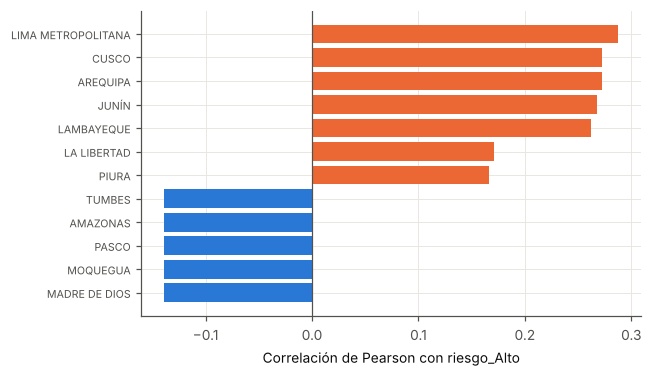

r(año, personas) = -0.035; ρ(mes, personas) = 0.026


In [ ]:
corr_matrix = std_format_df.drop(columns=["riesgo_Bajo", "riesgo_Medio"]).corr()
print("Columnas con varianza cero (r = NaN):", [c for c in std_format_df if std_format_df[c].var() == 0])
corr_personas = corr_matrix["personas"].drop("personas").sort_values(ascending=False)
corr_alto = corr_matrix["riesgo_Alto"].drop(["riesgo_Alto", "personas"]).sort_values(ascending=False)
display(pd.DataFrame({"r_con_personas": corr_personas.head(6)}).round(3))
display(pd.DataFrame({"r_con_riesgo_Alto": pd.concat([corr_alto.head(6), corr_alto.tail(4)])}).round(3))

fig, ax = plt.subplots(figsize=(6, 3.5))
top = corr_alto.reindex(corr_alto.abs().sort_values(ascending=False).index).head(12)
ax.barh(range(len(top)), top.values, color=[NARANJA if v > 0 else AZUL for v in top.values])
ax.set_yticks(range(len(top)), [t.replace("dpto_hecho_", "") for t in top.index], fontsize=7)
ax.invert_yaxis(); ax.axvline(0, color="#52514e", lw=0.8); ax.set_xlabel("Correlación de Pearson con riesgo_Alto")
plt.tight_layout(); plt.show()

r_anio = stats.pearsonr(panel["anio"], panel["personas"])
r_mes = stats.spearmanr(panel["mes"], panel["personas"])
print(f"r(año, personas) = {r_anio.statistic:.3f}; ρ(mes, personas) = {r_mes.statistic:.3f}")

### 9.1 Estructura multivariada de los departamentos
Matriz de perfiles $\mathbf{X} \in \mathbb{R}^{26 \times 6}$: tasa por 100,000, % de mujeres, % de menores, % de extranjeros,
coeficiente de variación mensual y log de la población. Centramos, calculamos covarianza y correlaciones, estandarizamos y aplicamos
PCA y K-medias **solo como exploración** (un algoritmo puede producir grupos aunque no existan subpoblaciones reales).

In [ ]:
w = df_clean
perfil_dpto = pd.DataFrame({
    "tasa_100k": territorio["tasa_anual_100k"],
    "pct_mujeres": w.dropna(subset=["sexo"]).groupby("dpto_hecho").apply(lambda g: 100 * g.loc[g.sexo == "F", "cantidad"].sum() / g["cantidad"].sum()),
    "pct_menores": w.dropna(subset=["menor"]).groupby("dpto_hecho").apply(lambda g: 100 * (g["menor"] * g["cantidad"]).sum() / g["cantidad"].sum()),
    "pct_extranjeros": w.dropna(subset=["extranjero"]).groupby("dpto_hecho").apply(lambda g: 100 * (g["extranjero"] * g["cantidad"]).sum() / g["cantidad"].sum()),
    "cv_mensual": panel.groupby("dpto_hecho")["personas"].agg(lambda s: s.std(ddof=1) / s.mean()),
    "log_poblacion": np.log10(pop_unidad.mean(axis=1)),
}).loc[departamentos]
X_num = perfil_dpto.to_numpy(); X_centered = X_num - X_num.mean(axis=0)
S_manual = X_centered.T @ X_centered / (len(X_num) - 1)
print("Media multivariada:", dict(zip(perfil_dpto.columns, X_num.mean(axis=0).round(2))))
print("Covarianza manual = pandas:", np.allclose(S_manual, perfil_dpto.cov().to_numpy()))

R_spearman = perfil_dpto.corr(method="spearman")
display(R_spearman.round(2))
Z = (perfil_dpto - perfil_dpto.mean()) / perfil_dpto.std(ddof=1)
pca = PCA(random_state=RANDOM_STATE).fit(Z)
display(pd.DataFrame({"autovalor": pca.explained_variance_, "PVE": pca.explained_variance_ratio_,
                      "PVE_acumulada": pca.explained_variance_ratio_.cumsum()},
                     index=[f"PC{i+1}" for i in range(Z.shape[1])]).round(3))
display(pd.DataFrame(pca.components_[:2].T, index=perfil_dpto.columns, columns=["PC1", "PC2"]).round(3))
sil = {k: silhouette_score(Z, KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit_predict(Z)) for k in range(2, 7)}
print("Silueta por K:", {k: round(v, 3) for k, v in sil.items()})

Media multivariada: {'tasa_100k': np.float64(62.4), 'pct_mujeres': np.float64(63.59), 'pct_menores': np.float64(61.78), 'pct_extranjeros': np.float64(1.57), 'cv_mensual': np.float64(0.34), 'log_poblacion': np.float64(5.92)}
Covarianza manual = pandas: True


,tasa_100k,pct_mujeres,pct_menores,pct_extranjeros,cv_mensual,log_poblacion
tasa_100k,1.00,-0.44,-0.17,-0.09,0.10,-0.22
pct_mujeres,-0.44,1.00,0.78,-0.16,0.02,-0.07
pct_menores,-0.17,0.78,1.00,-0.33,0.18,-0.29
pct_extranjeros,-0.09,-0.16,-0.33,1.00,-0.29,0.20
cv_mensual,0.10,0.02,0.18,-0.29,1.00,-0.87
log_poblacion,-0.22,-0.07,-0.29,0.20,-0.87,1.00


,autovalor,PVE,PVE_acumulada
PC1,2.088,0.348,0.348
PC2,1.837,0.306,0.654
PC3,0.994,0.166,0.820
PC4,0.734,0.122,0.942
PC5,0.200,0.033,0.976
PC6,0.146,0.024,1.000


,PC1,PC2
tasa_100k,-0.214,0.448
pct_mujeres,0.542,-0.386
pct_menores,0.600,-0.173
pct_extranjeros,-0.176,-0.061
cv_mensual,0.301,0.581
log_poblacion,-0.423,-0.528


Silueta por K: {2: 0.224, 3: 0.256, 4: 0.275, 5: 0.281, 6: 0.238}


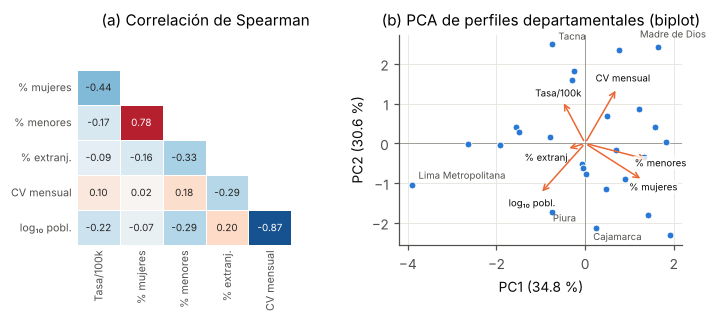

In [ ]:
etiquetas = ["Tasa/100k", "% mujeres", "% menores", "% extranj.", "CV mensual", "log₁₀ pobl."]
fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.0), gridspec_kw={"width_ratios": [1, 1.1]})
mask = np.triu(np.ones_like(R_spearman, dtype=bool), k=0)
sns.heatmap(R_spearman, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f", annot_kws={"size": 6.5},
            xticklabels=etiquetas, yticklabels=etiquetas, cbar=False, linewidths=0.5, linecolor="white", ax=axes[0])
axes[0].grid(False); axes[0].set_xticklabels(etiquetas[:-1] + [""]); axes[0].set_yticklabels([""] + etiquetas[1:])
axes[0].set_title("(a) Correlación de Spearman"); axes[0].tick_params(labelsize=7, length=0)
scores = pca.transform(Z)[:, :2]
axes[1].scatter(scores[:, 0], scores[:, 1], s=20, color=AZUL, edgecolor="white", lw=0.6, zorder=3)
destacar = {"LIMA METROPOLITANA": (4, 4), "MADRE DE DIOS": (-12, 6), "TACNA": (4, 3), "CAJAMARCA": (-50, -3), "PIURA": (-28, 4)}
for (x, y_), d in zip(scores, perfil_dpto.index):
    if d in destacar:
        axes[1].annotate(nombre_bonito(d), (x, y_), xytext=destacar[d], textcoords="offset points", fontsize=6.3, color="#52514e")
for (c1, c2), et in zip(pca.components_[:2].T, etiquetas):
    axes[1].annotate("", xy=(2.4 * c1, 2.4 * c2), xytext=(0, 0), arrowprops={"arrowstyle": "->", "color": NARANJA, "lw": 1.0})
    pos = (-0.85, -0.35) if et == "% extranj." else (2.4 * c1 * 1.18, 2.4 * c2 * 1.18)
    axes[1].text(*pos, et, color="#0b0b0b", fontsize=6.3, ha="center", va="center",
                 bbox={"boxstyle": "round,pad=0.1", "fc": "white", "ec": "none", "alpha": 0.8})
axes[1].axhline(0, color=GRIS, lw=0.5); axes[1].axvline(0, color=GRIS, lw=0.5)
axes[1].set_xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f} %)")
axes[1].set_ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f} %)")
axes[1].set_title("(b) PCA de perfiles departamentales (biplot)")
plt.tight_layout(); fig.savefig(FIG_DIR / "figura7_multivariado.png", bbox_inches="tight"); plt.show()

### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Qué variables se mueven juntas? ¿Hay grupos naturales de departamentos?

**🛠️ ¿Cómo lo hicimos?**  
Calculamos correlaciones (qué tanto suben o bajan dos variables a la vez) y aplicamos técnicas para resumir y agrupar departamentos (PCA y K-medias).

**📊 ¿Qué encontramos?**

- Ser Lima Metropolitana explica casi todo el volumen de casos: la correlación es 0.93, muy cerca del máximo de 1.
- El año y el mes casi no se relacionan con el número de casos.
- Los departamentos pequeños tienen cifras más inestables de un mes a otro.
- Al intentar formar grupos de departamentos parecidos, los grupos salieron débiles: no hay «familias» claras de departamentos.

**💡 ¿Qué significa?**  
La identidad del departamento es la información más importante. Por eso esperamos que un modelo de aprendizaje automático mejore solo un poco a una regla sencilla basada en el historial de cada departamento.

<details>
<summary><b>📐 Detalle técnico (cifras y pruebas estadísticas) — clic para ver</b></summary>

La correlación del número de personas con la dummy de Lima Metropolitana es r = .928, y la del nivel alto con las dummies de Lima Metropolitana, Cusco, Arequipa, Junín y Lambayeque está entre .26 y .29: la identidad del departamento explica la mayor parte de la variación. El año (r = −.035) y el mes (ρ = .026) casi no se relacionan con el número de personas. En la estructura multivariada de los 26 departamentos, el porcentaje de mujeres se asocia con el de menores (ρ = .78) y el coeficiente de variación mensual con la población (ρ = −.87: los departamentos pequeños son más inestables). Los dos primeros componentes principales explican el 65.4 % de la varianza (34.8 % y 30.6 %): el primero contrapone composición demográfica y tamaño, y el segundo, tasa y variabilidad frente a tamaño; Lima Metropolitana queda aislada. K-medias obtuvo siluetas de .22 a .28 para 2 a 6 grupos, demasiado bajas para afirmar que existan grupos naturales de departamentos.

</details>

## Paso 10: Discretización
Discretizamos el número de personas por departamento-mes en 3 categorías de **igual frecuencia** (`pd.qcut`): así se construye el
nivel de riesgo. A diferencia del cuaderno de clase, los cortes se calculan **solo con el entrenamiento (2019–2023)** y se aplican
sin recalcular a la prueba (2024–2025); calcularlos con toda la base sería una fuga de información. Comparamos además con
intervalos de **igual ancho** (`pd.cut`).

Cortes de igual frecuencia (solo train): [  0.  29.  59. 910.]
Umbrales de la Actividad 1: [29. 59.]
Cortes si se usara toda la base (fuga): [28. 59.]


,Entrenamiento (2019–2023),Prueba (2024–2025),Entrenamiento (2019–2023) %,Prueba (2024–2025) %
riesgo,,,,
Bajo,531,244,34.0,39.1
Medio,523,175,33.5,28.0
Alto,506,205,32.4,32.9


,min,max,median
riesgo,,,
Bajo,0,29,16.0
Medio,30,59,42.0
Alto,60,910,85.0


KS train vs prueba: D = 0.051, p = 0.1977 | χ² de clases: χ²(2) = 7.43, p = 0.0243, V = 0.058
Igual ancho (pd.cut) en train: {'Bajo': 1503, 'Medio': 43, 'Alto': 14} | cortes: [-9.000e-01  3.033e+02  6.067e+02  9.100e+02]


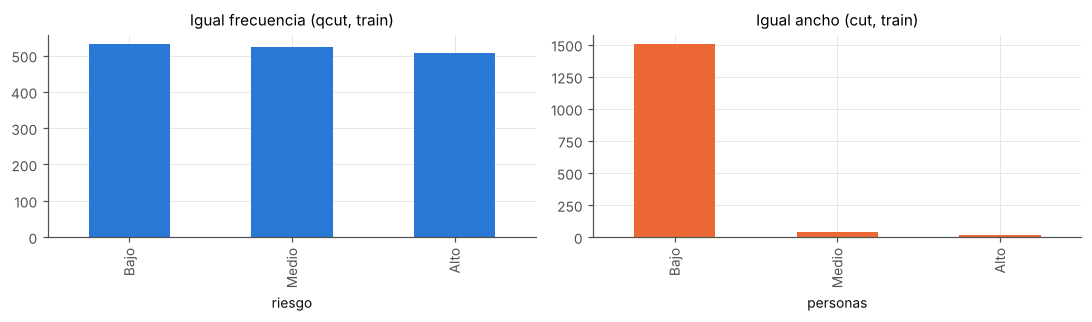

In [ ]:
train = panel[panel["anio"] <= 2023].copy(); test = panel[panel["anio"] >= 2024].copy()
bins_train, cortes = pd.qcut(train["personas"], 3, labels=["Bajo", "Medio", "Alto"], retbins=True)
print("Cortes de igual frecuencia (solo train):", cortes.round(2))
print("Umbrales de la Actividad 1:", UMBRALES_TRAIN)
cortes_total = np.quantile(panel["personas"], [1 / 3, 2 / 3])
print("Cortes si se usara toda la base (fuga):", cortes_total)

dis_df = pd.DataFrame({
    "Entrenamiento (2019–2023)": train["riesgo"].value_counts().reindex(["Bajo", "Medio", "Alto"]),
    "Prueba (2024–2025)": test["riesgo"].value_counts().reindex(["Bajo", "Medio", "Alto"])})
display(dis_df.assign(**{c + " %": 100 * dis_df[c] / dis_df[c].sum() for c in dis_df}).round(1))
display(train.groupby("riesgo", observed=True)["personas"].agg(["min", "max", "median"]))
ks = stats.ks_2samp(train["personas"], test["personas"])
chi_split = stats.chi2_contingency(dis_df.T)
print(f"KS train vs prueba: D = {ks.statistic:.3f}, p = {ks.pvalue:.4f} | "
      f"χ² de clases: χ²({chi_split.dof}) = {chi_split.statistic:.2f}, p = {chi_split.pvalue:.4f}, "
      f"V = {np.sqrt(chi_split.statistic / len(panel)):.3f}")

igual_ancho = pd.cut(train["personas"], 3, labels=["Bajo", "Medio", "Alto"])
print("Igual ancho (pd.cut) en train:", igual_ancho.value_counts().reindex(["Bajo", "Medio", "Alto"]).to_dict(),
      "| cortes:", np.round(pd.cut(train["personas"], 3, retbins=True)[1], 1))

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
train["riesgo"].value_counts().reindex(["Bajo", "Medio", "Alto"]).plot(kind="bar", ax=ax[0], color=AZUL); ax[0].set_title("Igual frecuencia (qcut, train)")
igual_ancho.value_counts().reindex(["Bajo", "Medio", "Alto"]).plot(kind="bar", ax=ax[1], color=NARANJA); ax[1].set_title("Igual ancho (cut, train)")
plt.tight_layout(); plt.show()

### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Dónde ponemos los cortes entre BAJO, MEDIO y ALTO?

**🛠️ ¿Cómo lo hicimos?**  
Ordenamos los meses de entrenamiento de menor a mayor número de casos y los partimos en tres partes iguales (terciles).

**📊 ¿Qué encontramos?**

- Los cortes quedaron así: BAJO de 0 a 29 personas, MEDIO de 30 a 59 y ALTO de 60 a más.
- Usamos solo los años de entrenamiento para fijar los cortes. Si hubiéramos usado también 2024–2025, el modelo habría «espiado» el futuro. A eso se le llama fuga de información.
- Si en lugar de partes iguales hubiéramos cortado por rangos del mismo ancho, casi todos los meses (1,503 de 1,560) habrían caído en BAJO, por culpa de los valores altísimos de Lima.

**💡 ¿Qué significa?**  
Los cortes 29 y 59 dan tres clases equilibradas y se calcularon sin hacer trampa con datos del futuro.

<details>
<summary><b>📐 Detalle técnico (cifras y pruebas estadísticas) — clic para ver</b></summary>

Con `pd.qcut` sobre el entrenamiento, los cortes son 0–29, 30–59 y 60–910 personas, idénticos a los umbrales de la Actividad 1, y producen clases casi balanceadas (531, 523 y 506). Si los cortes se calcularan con toda la base, el primero bajaría a 28: una fuga pequeña, pero real. En la prueba, con los mismos cortes, las clases quedan en 39.1 %, 28.0 % y 32.9 %; la distribución del número de personas no cambia (KS: D = .051, p = .198), pero las proporciones de clase sí (χ²(2) = 7.43, p = .024, V = .058), probablemente por desplazamientos de departamento-mes situados cerca de los umbrales. La discretización de igual ancho (`pd.cut`) sería inútil: por el extremo de Lima, 1,503 de 1,560 meses caerían en «Bajo» y solo 14 en «Alto».

</details>

## Paso 11: Escalamiento y normalización de atributos
Aplicamos normalización Min-Max $x_{new} = \frac{x - x_{min}}{x_{max} - x_{min}}$, estandarización z $x_{new} = \frac{x - \mu}{\sigma}$
y escalamiento robusto $x_{new} = \frac{x - \text{mediana}}{IQR}$ al número de personas por departamento-mes, que tiene un valor
extremo legítimo (Lima Metropolitana), como el ejemplo de los juguetes del cuaderno de clase. Todos los escaladores se **ajustan solo
con entrenamiento**. Finalmente armamos el preprocesamiento del modelo (`ColumnTransformer`) y verificamos que no hubo fuga.

,min,max,rango_P5_P95_sin_Lima,pct_del_rango_total
escalador,,,,
Min-Max,0.000,1.000,0.107,10.659
Z-score,-0.624,8.063,0.926,10.659
Robusto,-0.911,19.311,2.156,10.659
Z-score sobre log(1 + y),-3.822,3.246,2.670,37.780


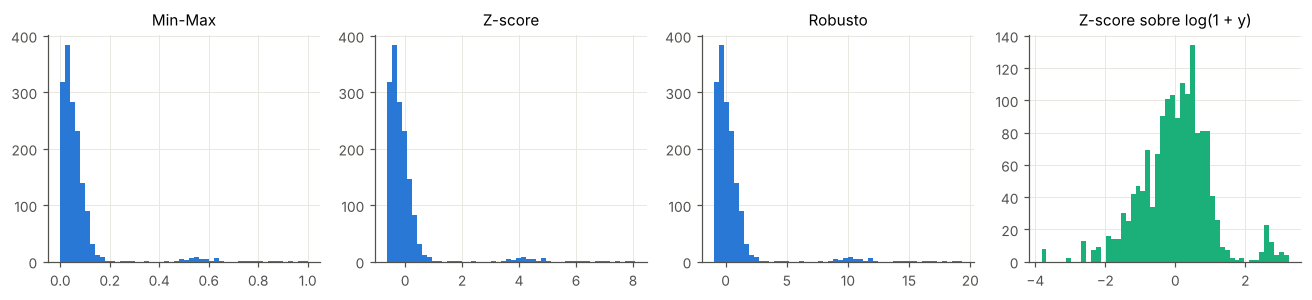

In [ ]:
y_train = train[["personas"]].to_numpy(float); y_test = test[["personas"]].to_numpy(float)
escaladores = {"Min-Max": MinMaxScaler(), "Z-score": StandardScaler(), "Robusto": RobustScaler()}
filas = []
mediana_no_lima = train.loc[train["dpto_hecho"] != "LIMA METROPOLITANA", "personas"].median()
for nombre, sc in escaladores.items():
    sc.fit(y_train)
    z = sc.transform(y_train).ravel()
    sin_lima = z[train["dpto_hecho"].to_numpy() != "LIMA METROPOLITANA"]
    filas.append({"escalador": nombre, "min": z.min(), "max": z.max(),
                  "rango_P5_P95_sin_Lima": np.percentile(sin_lima, 95) - np.percentile(sin_lima, 5),
                  "pct_del_rango_total": 100 * (np.percentile(sin_lima, 95) - np.percentile(sin_lima, 5)) / (z.max() - z.min())})
escala_df = pd.DataFrame(filas).set_index("escalador")
z_log = StandardScaler().fit(np.log1p(y_train)).transform(np.log1p(y_train)).ravel()
sl = z_log[train["dpto_hecho"].to_numpy() != "LIMA METROPOLITANA"]
escala_df.loc["Z-score sobre log(1 + y)"] = [z_log.min(), z_log.max(), np.percentile(sl, 95) - np.percentile(sl, 5),
                                             100 * (np.percentile(sl, 95) - np.percentile(sl, 5)) / (z_log.max() - z_log.min())]
display(escala_df.round(3))

fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
for ax, (nombre, sc) in zip(axes, list(escaladores.items())):
    ax.hist(sc.transform(y_train).ravel(), bins=50, color=AZUL); ax.set_title(nombre)
axes[3].hist(z_log, bins=50, color=VERDEAGUA); axes[3].set_title("Z-score sobre log(1 + y)")
plt.tight_layout(); plt.show()

In [ ]:
# Preprocesamiento del modelo (Actividad 1): composición demográfica histórica calculada SOLO con filas de entrenamiento
filas_train = df_clean[df_clean["anio"] <= 2023]
def composicion(filas_df):
    g = filas_df.groupby("dpto_hecho")
    return pd.DataFrame({
        "prop_mujeres": g.apply(lambda x: (x["cantidad"] * (x["sexo"] == "F")).sum() / x.loc[x["sexo"].notna(), "cantidad"].sum()),
        "prop_menores": g.apply(lambda x: (x["cantidad"] * x["menor"].fillna(0)).sum() / x.loc[x["menor"].notna(), "cantidad"].sum()),
        "prop_extranjeros": g.apply(lambda x: (x["cantidad"] * x["extranjero"].fillna(0)).sum() / x.loc[x["extranjero"].notna(), "cantidad"].sum()),
    })
comp_train = composicion(filas_train)
for parte in (train, test):
    for c in comp_train.columns:
        parte["hist_" + c] = parte["dpto_hecho"].map(comp_train[c])

mes_ciclico = FunctionTransformer(lambda m: np.c_[np.sin(2 * np.pi * np.asarray(m) / 12), np.cos(2 * np.pi * np.asarray(m) / 12)],
                                  feature_names_out=lambda self, names: ["mes_sin", "mes_cos"])
preprocessor = ColumnTransformer([
    ("departamento", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["dpto_hecho"]),
    ("mes", mes_ciclico, ["mes"]),
    ("anio", StandardScaler(), ["anio"]),
    ("composicion", "passthrough", ["hist_prop_mujeres", "hist_prop_menores", "hist_prop_extranjeros"]),
])
X_train_transformed = preprocessor.fit_transform(train)
X_test_transformed = preprocessor.transform(test)
print("X_train:", X_train_transformed.shape, "| X_test:", X_test_transformed.shape)

# Verificación: los parámetros aprendidos son los del entrenamiento, no los de toda la base
scaler = preprocessor.named_transformers_["anio"]
comp_total = composicion(df_clean)
preprocessing_parameters = pd.DataFrame({
    "aprendido_en_train": [scaler.mean_[0], np.sqrt(scaler.var_[0]), UMBRALES_TRAIN[0], UMBRALES_TRAIN[1], comp_train["prop_menores"].mean()],
    "calculado_en_train": [train["anio"].mean(), train["anio"].std(ddof=0), *np.quantile(train["personas"], [1/3, 2/3]), composicion(filas_train)["prop_menores"].mean()],
    "si_se_usara_toda_la_base": [panel["anio"].mean(), panel["anio"].std(ddof=0), *cortes_total, comp_total["prop_menores"].mean()],
}, index=["media del año", "DE del año", "umbral Bajo/Medio", "umbral Medio/Alto", "prop. menores (promedio dptos)"])
display(preprocessing_parameters.round(4))
print("Parámetros = estadísticos de entrenamiento:",
      np.allclose(preprocessing_parameters["aprendido_en_train"], preprocessing_parameters["calculado_en_train"]))

X_train: (1560, 32) | X_test: (624, 32)


,aprendido_en_train,calculado_en_train,si_se_usara_toda_la_base
media del año,2021.0000,2021.0000,2022.0000
DE del año,1.4142,1.4142,2.0000
umbral Bajo/Medio,29.0000,29.0000,28.0000
umbral Medio/Alto,59.0000,59.0000,59.0000
prop. menores (promedio dptos),0.6355,0.6355,0.6178


Parámetros = estadísticos de entrenamiento: True


### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Cómo ponemos todas las variables en una escala comparable?

**🛠️ ¿Cómo lo hicimos?**  
Probamos tres métodos para reescalar los números (Min-Max, puntuación z y escalado robusto) y una transformación con logaritmo.

**📊 ¿Qué encontramos?**

- Con los tres métodos, Lima es tan grande que el resto de los departamentos queda «aplastado» en una franja muy pequeña de la escala (el 10.7 % del rango).
- Al aplicar primero un logaritmo, que reduce los números grandes, los departamentos se reparten mejor y pasan a ocupar el 37.8 % del rango.
- Las tablas finales quedaron listas: 1,560 filas para entrenar y 624 para probar, con 32 columnas cada una.
- Todos los ajustes se calcularon solo con los datos de entrenamiento.

**💡 ¿Qué significa?**  
Los datos ya están limpios, ordenados y en una escala adecuada para entrenar los modelos de la siguiente etapa.

<details>
<summary><b>📐 Detalle técnico (cifras y pruebas estadísticas) — clic para ver</b></summary>

Min-Max, z-score y el escalador robusto son transformaciones lineales: cambian la escala, pero no la forma. En los tres, el 90 % central de los departamento-mes sin Lima ocupa solo el 10.7 % del rango total (un intervalo de apenas 0.11 en la escala Min-Max de 0 a 1), igual que en el ejemplo de los juguetes del cuaderno de clase; el z-score llega a 8.06 y el robusto a 19.31 por el extremo de Lima. Solo una transformación no lineal cambia esto: con z-score sobre log(1 + y), ese 90 % central ocupa el 37.8 % del rango. Por eso, para la regresión usamos log(1 + y). El preprocesamiento final produce matrices de 1,560 × 32 (entrenamiento) y 624 × 32 (prueba), y la verificación confirma que todos los parámetros (media y DE del año: 2021 y 1.41; umbrales 29 y 59; proporción media de menores .636) son los del entrenamiento; con toda la base habrían sido 2022, 2.00, 28 y .618.

</details>

## Paso 12: Bitácora de decisiones, memoria y exportación
La reproducibilidad exige registrar no solo el código, sino los hechos observados, las decisiones y su justificación. Todas las
tablas informativas se guardan en CSV para incluirlas en el informe.

In [ ]:
def memory_megabytes(frame):
    return frame.memory_usage(deep=True).sum() / 1024 ** 2
df_cat = df_clean.copy()
for c in ["dpto_hecho", "prov_hecho", "dist_hecho", "ubigeo_hecho", "sexo", "nacionalidad"]:
    df_cat[c] = df_cat[c].astype("category")
display(pd.Series({"texto (lectura cruda)": memory_megabytes(raw), "tipos depurados": memory_megabytes(df_clean),
                   "categorías + enteros pequeños": memory_megabytes(df_cat)}, name="MB").round(2).to_frame())

decision_log = pd.DataFrame([
    ("Procedencia", "Archivo MININTER verificado por SHA-256; 2025 preliminar", "Registrar fuente, licencia, huella y versión", "Trazabilidad"),
    ("Esquema", "30.7 % de las filas (724 códigos) pierden el cero inicial del UBIGEO con tipos inferidos", "Leer todas las columnas como texto y validar los seis dígitos", "Integridad del esquema"),
    ("Ausencia", "Vacíos no documentados en SEXO y RANGO_EDAD; «NO INDICA» en NACIONALIDAD", "Normalizar a valores faltantes y conservar las filas", "Ausencia encubierta"),
    ("Ausencia", "La ausencia de RANGO_EDAD depende del año", "Categoría «SIN DATO» o imputación por año; no eliminar filas", "Mecanismo MAR plausible"),
    ("Distribución", "Asimetría positiva fuerte de CANTIDAD y del número de casos", "Usar mediana y cuantiles; log(1 + y) en la regresión", "Colas pesadas legítimas"),
    ("Extremos", "Valores inusuales concentrados en Lima Metropolitana", "Conservarlos y no recortarlos", "Subpoblación real"),
    ("Categorías", "Nombres de distrito repetidos y códigos inconsistentes", "Usar el UBIGEO como clave, nunca el nombre", "Coherencia de códigos"),
    ("Categorías", "57 nacionalidades con menos del 1 % de las personas", "Agrupar en peruana, venezolana, otras y «SIN DATO»", "Categorías raras"),
    ("Territorio", "El número de casos sigue a la población", "Reportar tasas por 100,000; no interpretar el conteo como riesgo individual", "Confusión por tamaño"),
    ("Codificación", "LabelEncoder impone un orden falso a nominales", "One-Hot para departamento; código ordinal solo para la edad", "Escala de medición"),
    ("Tiempo", "Quiebre de 2020, estacionalidad débil y dependencia entre meses", "Partición temporal 2019–2023 / 2024–2025; mes cíclico", "Dependencia temporal"),
    ("Escalamiento", "Lima Metropolitana comprime la escala con Min-Max y z", "Escalar log(1 + y), ajustado solo con entrenamiento", "Valores extremos"),
    ("Fuga", "Umbrales y composición demográfica se ajustan con datos", "Estimarlos solo con entrenamiento", "Prevención de fuga"),
], columns=["tema", "hecho_observado", "decision", "justificacion"])
display(decision_log)

dictionary_df = contraste.copy()
dictionary_df["tipo_analitico"] = ["de intervalo (temporal)", "cíclica (periodo 12)", "nominal (identificador)", "nominal", "nominal",
                                   "nominal", "nominal binaria", "ordinal", "nominal", "de razón (conteo)"]
decision_log.to_csv(OUT_DIR / "decision_log.csv", index=False, encoding="utf-8")
dictionary_df.to_csv(OUT_DIR / "data_dictionary_initial.csv", index=False, encoding="utf-8")
numeric_profile.round(4).to_csv(OUT_DIR / "perfil_numerico.csv", encoding="utf-8")
territorio.round(3).to_csv(OUT_DIR / "territorio_tasas.csv", encoding="utf-8")
missing_by_year.round(3).to_csv(OUT_DIR / "ausencia_por_anio.csv", encoding="utf-8")
perfil_dpto.round(4).to_csv(OUT_DIR / "perfil_departamental.csv", encoding="utf-8")
comparacion_clases.round(4).to_csv(OUT_DIR / "comparacion_niveles_riesgo.csv", encoding="utf-8")
escala_df.round(4).to_csv(OUT_DIR / "comparacion_escaladores.csv", encoding="utf-8")
print("Archivos:", sorted(p.name for p in OUT_DIR.iterdir()))
print("Figuras:", sorted(p.name for p in FIG_DIR.iterdir()))

,MB
texto (lectura cruda),44.21
tipos depurados,28.80
categorías + enteros pequeños,3.20


,tema,hecho_observado,decision,justificacion
0,Procedencia,Archivo MININTER verificado por SHA-256; 2025 ...,"Registrar fuente, licencia, huella y versión",Trazabilidad
1,Esquema,30.7 % de las filas (724 códigos) pierden el c...,Leer todas las columnas como texto y validar l...,Integridad del esquema
2,Ausencia,Vacíos no documentados en SEXO y RANGO_EDAD; «...,Normalizar a valores faltantes y conservar las...,Ausencia encubierta
3,Ausencia,La ausencia de RANGO_EDAD depende del año,Categoría «SIN DATO» o imputación por año; no ...,Mecanismo MAR plausible
4,Distribución,Asimetría positiva fuerte de CANTIDAD y del nú...,Usar mediana y cuantiles; log(1 + y) en la reg...,Colas pesadas legítimas
5,Extremos,Valores inusuales concentrados en Lima Metropo...,Conservarlos y no recortarlos,Subpoblación real
6,Categorías,Nombres de distrito repetidos y códigos incons...,"Usar el UBIGEO como clave, nunca el nombre",Coherencia de códigos
7,Categorías,57 nacionalidades con menos del 1 % de las per...,"Agrupar en peruana, venezolana, otras y «SIN D...",Categorías raras
8,Territorio,El número de casos sigue a la población,"Reportar tasas por 100,000; no interpretar el ...",Confusión por tamaño
9,Codificación,LabelEncoder impone un orden falso a nominales,One-Hot para departamento; código ordinal solo...,Escala de medición


Archivos: ['ausencia_por_anio.csv', 'comparacion_escaladores.csv', 'comparacion_niveles_riesgo.csv', 'data_dictionary_initial.csv', 'decision_log.csv', 'panel_dpto_mes_numerico.csv', 'perfil_departamental.csv', 'perfil_numerico.csv', 'territorio_tasas.csv']
Figuras: ['figura4_distribucion_dpto_mes.png', 'figura5_tasa_departamento.png', 'figura6_temporalidad.png', 'figura7_multivariado.png']


### 💬 Interpretación

**❓ ¿Qué queríamos saber?**  
¿Cómo dejamos constancia de lo que hicimos?

**🛠️ ¿Cómo lo hicimos?**  
Guardamos en archivos CSV cada tabla de resultados y una «bitácora», que es una lista de cada decisión tomada y su motivo.

**📊 ¿Qué encontramos?**

- Todas las tablas quedaron guardadas en la carpeta salidas_eda y los gráficos en la carpeta figuras.
- Al guardar los textos como «categorías», la tabla pasa de ocupar 44 MB de memoria a solo 3 MB.

**💡 ¿Qué significa?**  
Cualquier persona puede revisar por qué tomamos cada decisión, y los resultados pueden pasarse directamente al informe.

## Síntesis del EDA

| Paso | Hallazgo principal | Implicancia para el modelado |
|---|---|---|
| 1. Carga | Filas = conteos con clave única; UBIGEO pierde ceros si se infiere el tipo; 6 discrepancias con el diccionario | Leer como texto; ponderar por `CANTIDAD` |
| 2. Faltantes | Vacíos y «NO INDICA»; la ausencia de edad depende del año | No eliminar filas; categoría «SIN DATO» |
| 3. Numéricos | Asimetría fuerte; extremos = Lima Metropolitana; conteo ∝ población | Mediana/cuantiles; log(1 + y); tasas |
| 4. Categóricos | Mujeres 61 %; 12–17 años 53 % (con edad registrada); Perú 97.7 %; 57 nacionalidades raras | Agrupar nacionalidades; UBIGEO como clave |
| 5. Cruces | Sexo × edad fuerte; el departamento casi determina el nivel de riesgo | Interpretar el riesgo como volumen |
| 6. Segmento | Mujeres de 12–17 años: 41.4 % del total, peso decreciente desde 2021 | Foco de prevención |
| 7. Clases | Las clases difieren en tasa por habitante; la composición difiere poco y el mes no distingue | Aporte modesto de la composición y del mes |
| 8. One-Hot | 26 columnas por departamento; LabelEncoder sería engañoso | One-Hot nominal, ordinal para edad |
| 9. Correlación | El departamento domina; mes y año aportan poco | Esperar ventaja pequeña sobre la regla histórica |
| 10. Discretización | Terciles 29 y 59 solo con train; igual ancho desbalancea | Evita fuga y clases vacías |
| 11. Escalamiento | Lima comprime la escala con Min-Max, z y robusto; solo log + z la corrige | Escalar en train y aplicar a prueba |

*El EDA reduce riesgos, pero no garantiza causalidad, generalización ni desempeño predictivo.*



Resumen

**1. ¿Los datos abiertos de personas desaparecidas son de buena calidad?**  
En general sí: hay muchos datos, no hay registros repetidos ni valores imposibles, y faltan muy pocos datos (menos del 1 %). Pero tienen defectos: el diccionario oficial no coincide con el archivo en 6 puntos, el código de ubicación pierde ceros si no se lee con cuidado, hay nacionalidades mal escritas y nombres de distrito repetidos. Sirven, pero hay que limpiarlos antes de usarlos.

**2. ¿Quiénes desaparecen más?**  
Las mujeres adolescentes de 12 a 17 años. Son el 41.4 % de todos los casos del país.

**3. ¿Dónde hay más desapariciones?**  
En número de casos, en Lima Metropolitana (un tercio del total). Pero en proporción a la población, el departamento más afectado es Tacna. Por eso hay que comparar con tasas por cada 100,000 habitantes.

**4. ¿Hay meses o épocas con más casos?**  
No hay un mes claramente peor que otro. Lo único que se nota es la gran caída de abril de 2020, por la cuarentena de la COVID-19.

**5. ¿Ha cambiado la situación con los años?**  
El registro ha mejorado, porque cada año faltan menos datos, y el peso de las adolescentes bajó de 45.7 % en 2021 a 37.6 % en 2025.

**6. ¿Qué hicimos con los datos faltantes?**  
No los borramos. Los marcamos como «SIN DATO» para no perder casos, sobre todo los de 2019 y 2020.

**7. ¿Cómo definimos el nivel de riesgo?**  
Para cada departamento y mes contamos los desaparecidos y lo clasificamos como BAJO (0–29), MEDIO (30–59) o ALTO (60 o más). Los cortes salen de dividir los meses de 2019–2023 en tres partes iguales.

**8. ¿Por qué separamos los datos por años y no al azar?**  
Porque lo que pasa en un mes se parece a lo del mes anterior. Para saber si el modelo de verdad predice, hay que entrenarlo con el pasado (2019–2023) y probarlo con el futuro (2024–2025).

**9. ¿Se puede predecir el nivel de riesgo?**  
El análisis indica que sí, pero el departamento es lo que más pesa. Por eso esperamos que el modelo mejore solo un poco a una regla simple basada en el historial de cada departamento. Eso se confirma en la etapa de modelado.

**10. ¿Qué aprendimos para el modelo?**  
Hay que usar tasas y no solo conteos, convertir los departamentos con One-Hot, usar logaritmo para que Lima no distorsione la escala y calcular todo solo con los datos de entrenamiento para no hacer trampa.